In [1]:
import os
import json
import pickle
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torch_geometric.nn.attention import PerformerAttention
from torch_geometric.nn.attention.performer import generalized_kernel
from torch_geometric.nn import GATv2Conv
from shapely.geometry import Point, LineString, Polygon

import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
from collections import Counter
import torch_geometric
from torch_geometric.data import Data
from shapely import wkt
import contextily as cx
import h3pandas
import seaborn as sns
from utils import *
import utils

# Purpose of this notebook is to build the attention graph
 It is the graph that is in the paper: https://arxiv.org/pdf/2502.12352



For each layer ℓ we want:

- the attention matrix A(ℓ) ∈ Rn×n , one for each head h
- Then we can fuse heads inside the layer
- hen we can multiply across layers: matrix multiplication in order to obtain a final attention matrix A ∈ Rn×n
- Then we can use this matrix to create a graph, and then we can use the graph to do whatever we want.

# Data processing
I'm just repeating the steps of Parish3 notebook, check it out for more details.

In [2]:
#load paris geoJson edge and nodes
paris_edges = gpd.read_file('paris_edges.geojson')
paris_nodes = gpd.read_file('paris_nodes.geojson')

#save nodes and edges to geojson
h3_edges = gpd.read_file('h3_edges.geojson')
h3_nodes = gpd.read_file('h3_nodes.geojson')
h3_nodes.index = h3_nodes['h3_09'] 
h3_nodes.drop(columns=['h3_09'], inplace=True)

Text(0.5, 1.0, 'Edges and Nodes')

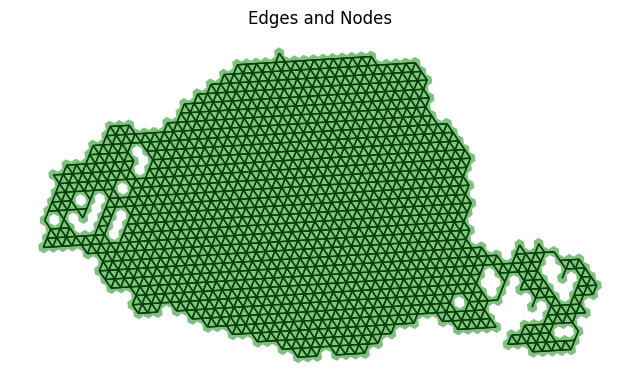

In [3]:
f, ax = plt.subplots(1, 1, figsize=(8, 8))
h3_edges.plot(ax=ax, color='black', linewidth=1, zorder =1)
h3_nodes.plot(ax=ax, color='green', markersize=1, zorder=2, alpha=0.5)
ax.set_axis_off()
plt.title('Edges and Nodes')

Basic feature dataset

In [4]:
device = 'cpu'
print(device)
basicHexes = h3_nodes.copy()
basicHexes = basicHexes[['Green View', 'geometry', 'x', 'y']]
y = basicHexes['Green View'].values
X = basicHexes[['x', 'y']].values
X = np.array(X)
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)
node_mapping = {node_id: idx for idx, node_id in enumerate(h3_nodes.index)}
reverse_mapping = {idx: h3_id for h3_id, idx in node_mapping.items()}
edge_index = []
for _, row in h3_edges.iterrows():
    source_idx = node_mapping[row['source']]
    target_idx = node_mapping[row['target']]
    edge_index.append([source_idx, target_idx]) # no need to add the reverse edge since edge already contains it
edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
transform = T.AddLaplacianEigenvectorPE(k = 20, attr_name= 'pe')
BasicData = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(y), edge_index = edge_index )
BasicData = transform(BasicData)
np.random.seed(0)
n_nodes = BasicData.num_nodes
indices = np.random.permutation(n_nodes)
train_idx = indices[:int(0.7 * n_nodes)]
val_idx = indices[int(0.7 * n_nodes):int(0.85 * n_nodes)]
test_idx = indices[int(0.85 * n_nodes):]
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True        
BasicData.train_mask = train_mask   
BasicData.val_mask = val_mask
BasicData.test_mask = test_mask
BasicData.to(device)

cpu


Data(x=[1228, 2], edge_index=[2, 6844], y=[1228], pe=[1228, 20], train_mask=[1228], val_mask=[1228], test_mask=[1228])

Complete Dataset aswell

In [5]:
completeHexes = h3_nodes.copy()
completeHexes = completeHexes.drop(columns=['geometry', 'Green View','osmid', 'Node Density', 'Street Length', 'Degree',
       'Clustering', 'Clustering (Weighted)', 'Closeness Centrality',
       'Betweenness Centrality', 'Eigenvector Centrality', 'Katz Centrality',
       'PageRank', 'Footprint Proportion', 'Footprint Mean', 'Footprint Stdev',
       'Perimeter Total', 'Perimeter Mean', 'Perimeter Stdev',
       'Complexity Mean', 'Complexity Stdev', 'Counts'])
completeHexes.head()
y = h3_nodes['Green View'].values
X = completeHexes.values
X = np.array(X)
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)
transform = T.AddLaplacianEigenvectorPE(k = 20, attr_name= 'pe')
CompleteData = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(y), edge_index = edge_index )
CompleteData = transform(CompleteData)
np.random.seed(10)
n_nodes = CompleteData.num_nodes
indices = np.random.permutation(n_nodes)
train_idx = indices[:int(0.7 * n_nodes)]
val_idx = indices[int(0.7 * n_nodes):int(0.85 * n_nodes)]
test_idx = indices[int(0.85 * n_nodes):]
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True
CompleteData.train_mask = train_mask    
CompleteData.val_mask = val_mask
CompleteData.test_mask = test_mask
CompleteData.to(device)

Data(x=[1228, 19], edge_index=[2, 6844], y=[1228], pe=[1228, 20], train_mask=[1228], val_mask=[1228], test_mask=[1228])

# Comparison To baseline models, not hybrids
## First a GAT model

In [6]:
class GAT_model(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        num_layers: int = 3,
        dropout: float = 0.4,
    ):
        super().__init__()
        
        # Input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        self.gat_norm = nn.LayerNorm(hidden_channels)
        # GAT layers
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # GAT component
                'gat': GATv2Conv(
                    hidden_channels, 
                    hidden_channels, 
                    heads=heads, 
                    concat=True, 
                    dropout=dropout
                ),

                #Normalization
                'gat_norm': nn.LayerNorm(hidden_channels*heads),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels*heads, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.layers.append(layer)
        
        # Output layer for prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def forward(self, x, pe, edge_index):
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Process through GAT layers
        for layer in self.layers:
            # Pre-normalization
            x_norm = layer['norm'](x)
            x_gat = layer['gat'](x_norm, edge_index)
            x_gat = layer['gat_norm'](x_gat)
            x_ff = layer['ffn'](x_gat)
            
            # Feed-forward network with residual
            x = x + x_ff
        
        # Final prediction
        return self.output_layer(x)
    
    def get_attention_weights(self, x, pe, edge_index, layer_idx=0):
        """Extract the attention weights from GATv2Conv for a specific layer.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            
        Returns:
            Tuple of (edge_index, attention_weights) where attention_weights has
            shape [num_edges, heads]
        """
        if layer_idx < 0 or layer_idx >= len(self.layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            
            # Process through previous layers
            for i in range(layer_idx):
                layer = self.layers[i]
                x_norm = layer['norm'](x)
                x_gat = layer['gat'](x_norm, edge_index)
                x_gat = layer['gat_norm'](x_gat)
                x_ff = layer['ffn'](x_gat)
                x = x + x_ff
            
            # Get the target layer
            layer = self.layers[layer_idx]
            x_norm = layer['norm'](x)
            
            # Return the edge_index and attention weights
            # Note: For GATv2Conv, we need to run a forward pass and 
            # access the _alpha attribute to get attention weights
            _, (att_edge_ind, attention_weights)= layer['gat'](x_norm, edge_index, return_attention_weights=True)
            
            # The attention weights will have shape [num_edges, heads]
            return att_edge_ind, attention_weights

# Create the model instance
gat_model = GAT_model(
    in_channels=CompleteData.num_features,
    pe_input_dim=CompleteData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    num_layers=8,
    dropout=0.4
)
gat_model.to(device)

assert gat_model(CompleteData.x, CompleteData.pe, CompleteData.edge_index).squeeze().shape == CompleteData.y.shape, "Model output shape does not match target shape"

In [7]:
LR = 0.001
EPOCHS = 1000

# Define loss and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(gat_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)

In [ ]:
# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train(gat_model, CompleteData, optimizer, criterion)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(gat_model, CompleteData, CompleteData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(gat_model.state_dict(), 'best_models_paris/best_hex_model_GNN.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate(gat_model, CompleteData, CompleteData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Final Test Results - Loss: 0.0053


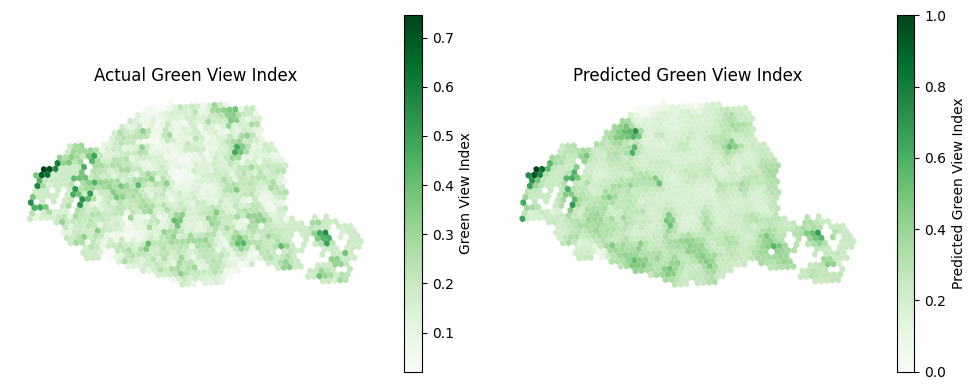

In [8]:
# load, evaluate and visualize the best model
evaluate_and_visualize_predictions(gat_model, CompleteData, 'best_models_paris/best_hex_model_GNN.pth', h3_nodes ,criterion)

Attention Graph computation and visualization

torch.Size([1228, 1228])


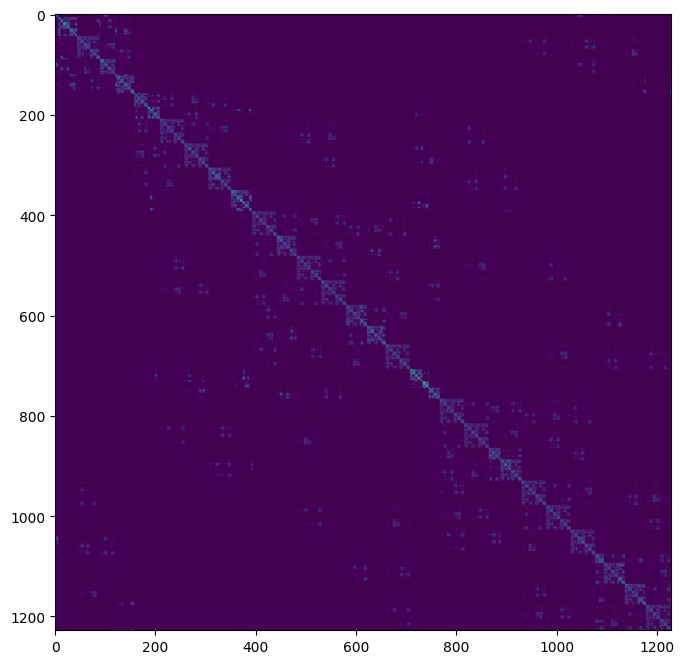

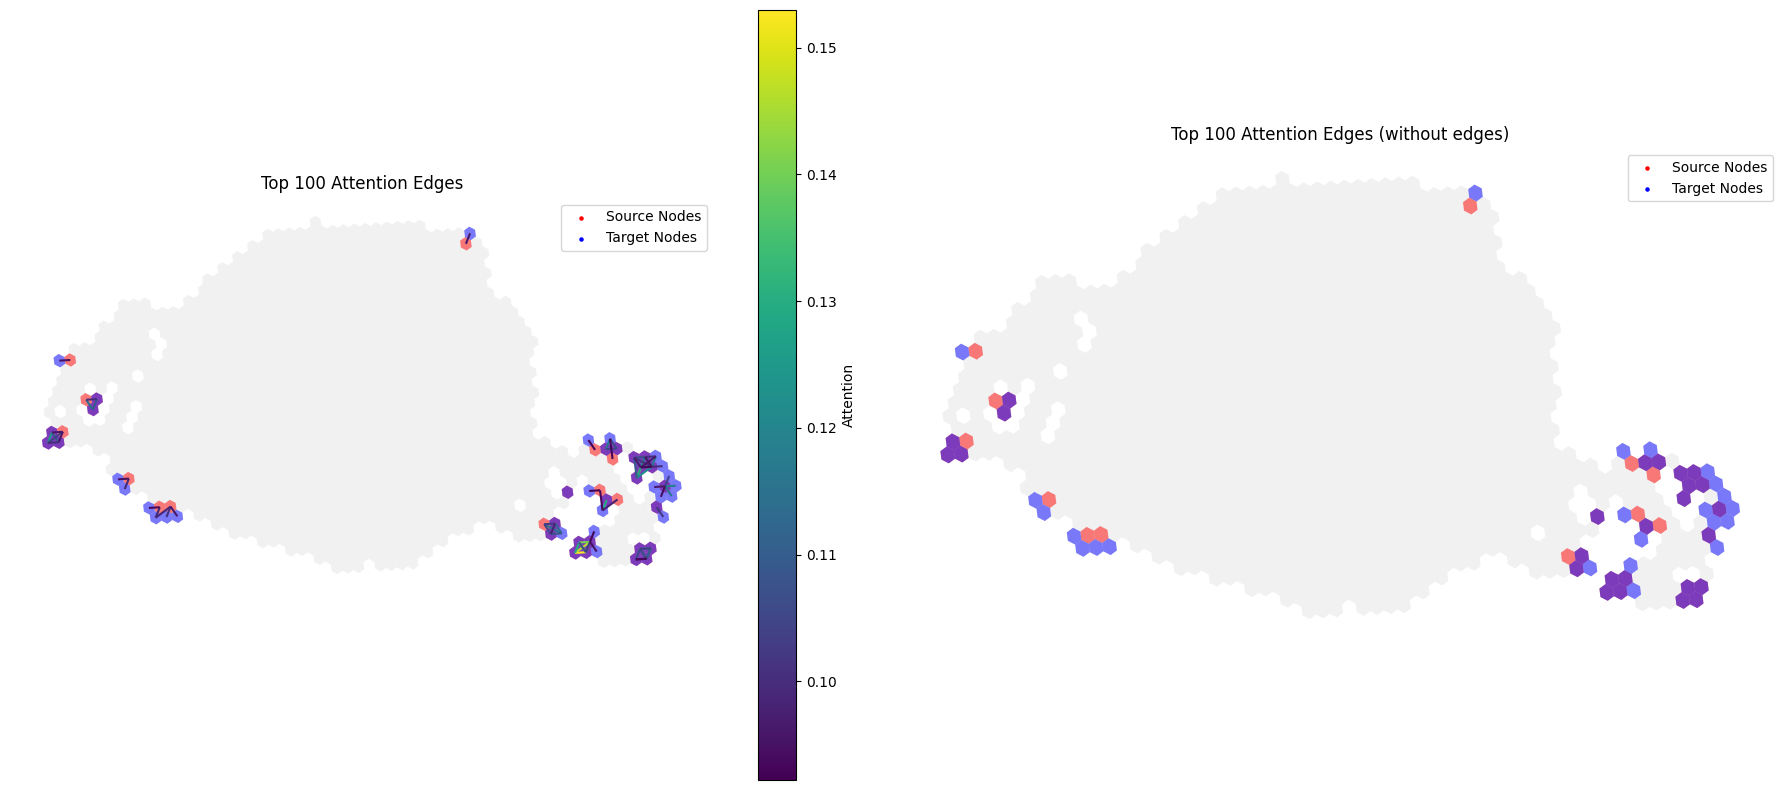

In [9]:
A_flow = make_attention_graph(gat_model, CompleteData, 'GATv2' ,fuse="mean")
print(A_flow.shape)

f, ax1 = plt.subplots(1, 1, figsize=(8, 8))
ax1.imshow(A_flow, cmap='viridis')

plot_top_k_attention_edges(A_flow.cpu().numpy(), h3_nodes, top_k=100)


### Repeating everything with basic data

In [10]:
# declare model with basic data
gat_model_basic = GAT_model(
    in_channels=BasicData.num_features,
    pe_input_dim=BasicData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    num_layers=8,
    dropout=0.4
)
gat_model_basic.to(device)
assert gat_model_basic(BasicData.x, BasicData.pe, BasicData.edge_index).squeeze().shape == BasicData.y.shape, "Model output shape does not match target shape"

In [11]:
EPOCHS = 1000
LR = 0.001
optimizer = torch.optim.Adam(gat_model_basic.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train(gat_model_basic, BasicData, optimizer, criterion)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(gat_model_basic, BasicData, BasicData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(gat_model_basic.state_dict(), 'best_models_paris/best_hex_model_GNN_basic.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate(gat_model_basic, BasicData, BasicData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0279, Val Loss: 0.0115, Test Loss: 0.0116, 
Epoch: 020, Train Loss: 0.0133, Val Loss: 0.0084, Test Loss: 0.0060, 
Epoch: 030, Train Loss: 0.0106, Val Loss: 0.0100, Test Loss: 0.0072, 
Epoch: 040, Train Loss: 0.0090, Val Loss: 0.0098, Test Loss: 0.0073, 
Epoch: 050, Train Loss: 0.0086, Val Loss: 0.0083, Test Loss: 0.0061, 
Epoch: 060, Train Loss: 0.0075, Val Loss: 0.0083, Test Loss: 0.0061, 
Epoch: 070, Train Loss: 0.0078, Val Loss: 0.0078, Test Loss: 0.0056, 
Epoch: 080, Train Loss: 0.0084, Val Loss: 0.0075, Test Loss: 0.0054, 
Epoch: 090, Train Loss: 0.0073, Val Loss: 0.0075, Test Loss: 0.0053, 
Epoch: 100, Train Loss: 0.0075, Val Loss: 0.0075, Test Loss: 0.0052, 
Epoch: 110, Train Loss: 0.0076, Val Loss: 0.0073, Test Loss: 0.0052, 
Epoch: 120, Train Loss: 0.0076, Val Loss: 0.0071, Test Loss: 0.0051, 
Epoch: 130, Train Loss: 0.0069, Val Loss: 0.0072, Test Loss: 0.0051, 
Epoch: 140, Train Loss: 0.0069, Val Loss: 0.0069, Test Loss: 0

Final Test Results - Loss: 0.0051


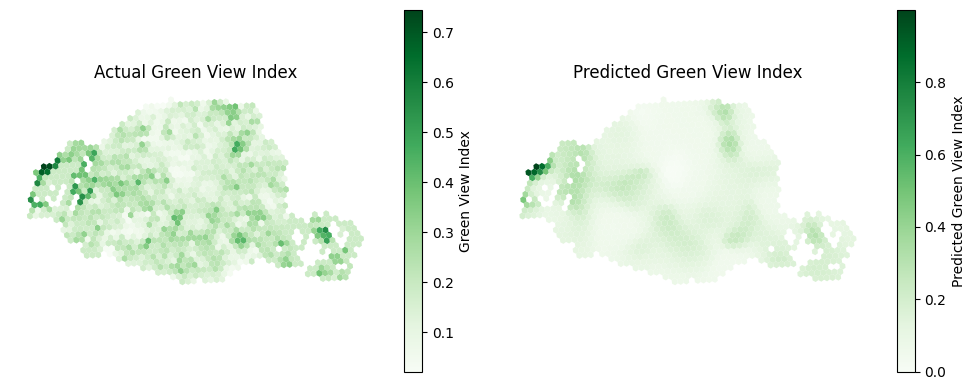

In [13]:
# load, evaluate and visualize the best model
evaluate_and_visualize_predictions(gat_model_basic, BasicData, 'best_models_paris/best_hex_model_GNN_basic.pth', h3_nodes, criterion)

torch.Size([1228, 1228])


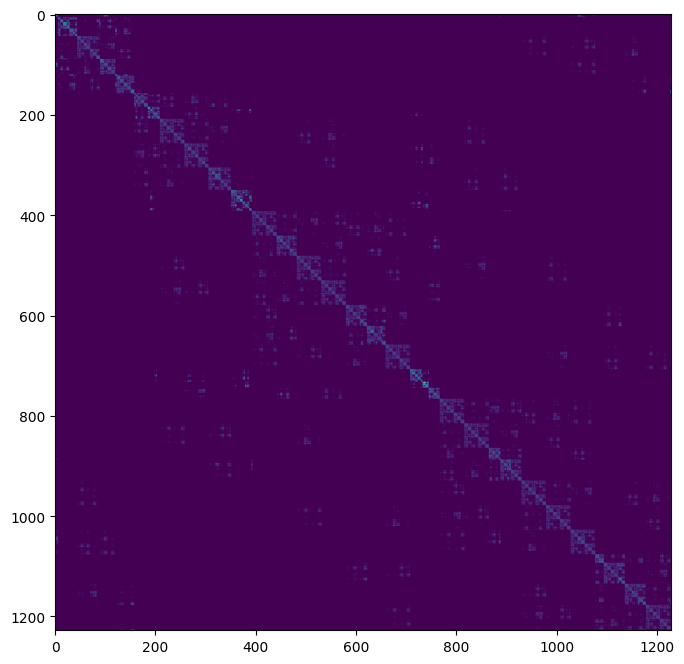

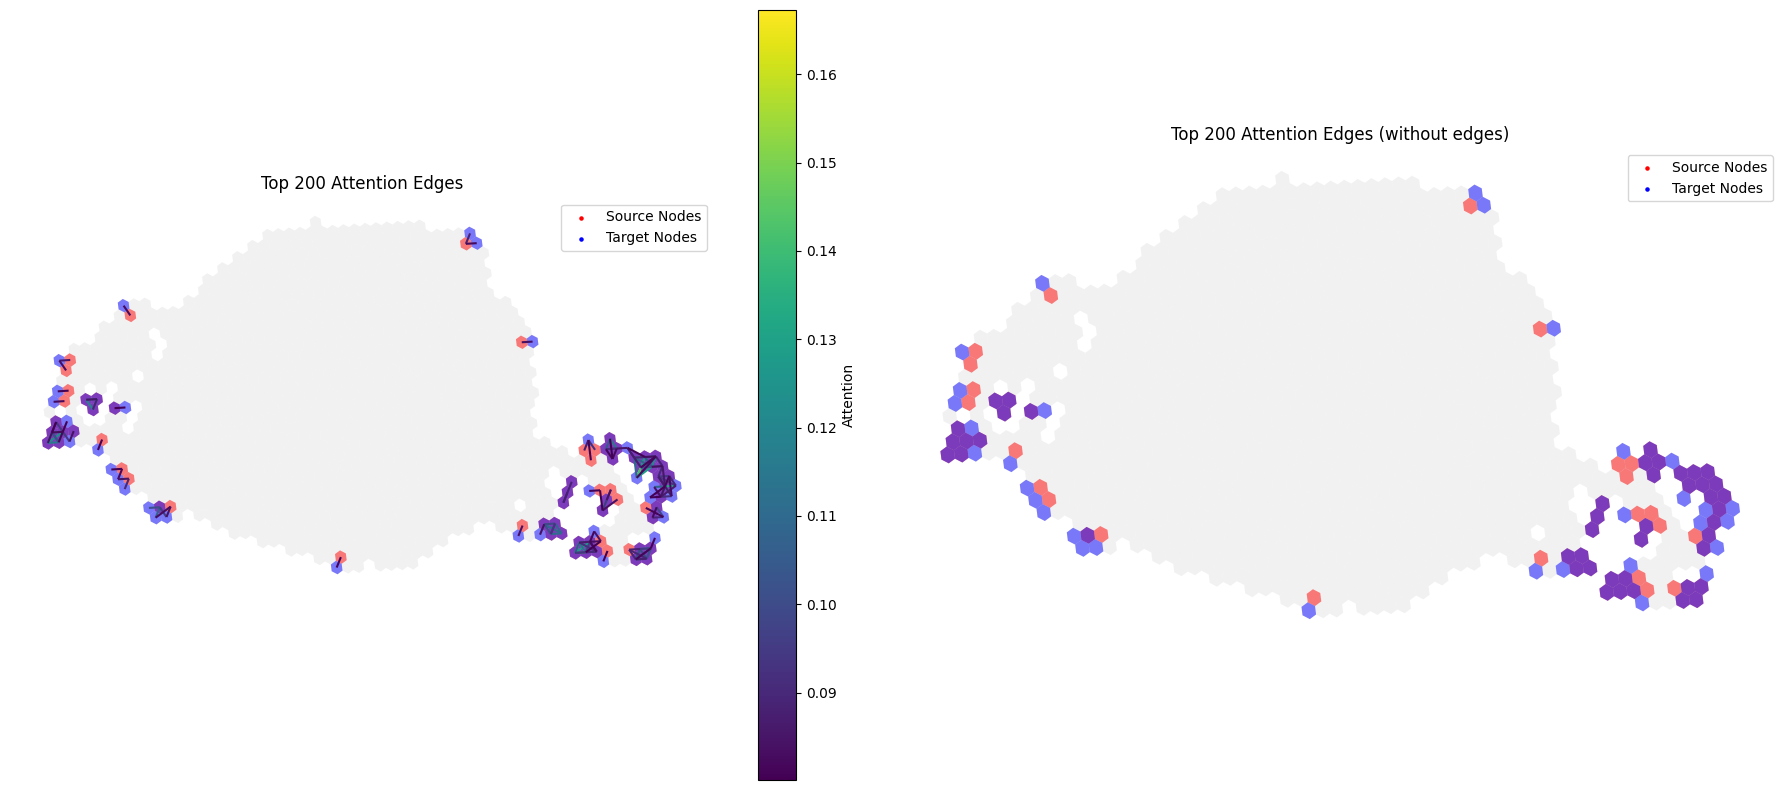

In [14]:
A_flow = make_attention_graph(gat_model_basic, BasicData, 'GATv2' ,fuse="mean")
print(A_flow.shape)

f, ax1 = plt.subplots(1, 1, figsize=(8, 8))
ax1.imshow(A_flow, cmap='viridis')

plot_top_k_attention_edges(A_flow.cpu().numpy(), h3_nodes, top_k=200)

## Full Performer model

In [7]:
class PerformerModel(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_layers: int = 3,
        dropout: float = 0.4,
    ):
        super().__init__()
        
        # Input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        self.trans_norm = nn.LayerNorm(hidden_channels)
        # Performer layers
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # Performer attention component only (no GAT)
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                # Normalization after attention
                
                'trans_norm': nn.LayerNorm(hidden_channels),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.layers.append(layer)
        
        # Output layer for prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def forward(self, x, pe, edge_index=None, batch=None):
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Process through Performer layers
        for layer in self.layers:
            # Pre-normalization
            x_norm = layer['norm'](x)
            
            # Performer attention
            x_perf = x_norm.unsqueeze(0)
            x_perf = layer['attention'](x_perf).squeeze(0)
            x_perf = layer['trans_norm'](x_perf)
            
            # Residual connection (simpler now - no need to combine GAT outputs)
            x_combined = x_perf + x
            
            # Feed-forward network with residual
            x = x_combined + layer['ffn'](x_combined)
        
        # Final prediction
        return self.output_layer(x)
    
    def get_performer_attention(self, x, pe, edge_index=None, layer_idx=0, mask=None):
        """Extract the attention approximation used by Performer for a specific layer."""
        if layer_idx < 0 or layer_idx >= len(self.layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            
            # Process through previous layers
            for i in range(layer_idx):
                layer = self.layers[i]
                x_norm = layer['norm'](x)
                x_trans = x_norm.unsqueeze(0)
                x_trans = layer['attention'](x_trans).squeeze(0)
                x_combined = x_trans + x
                x = x_combined + layer['ffn'](x_combined)
            
            # Get the target layer
            layer = self.layers[layer_idx]
            x_norm = layer['norm'](x)
            x = x_norm.unsqueeze(0)
            
            # Get Q, K, V projections
            attention = layer['attention']
            B, N, C = x.shape
            q, k, v = attention.q(x), attention.k(x), attention.v(x)
            
            # Reshape to multi-head format
            q, k, v = map(
                lambda t: t.reshape(B, N, attention.heads, attention.head_channels).permute(
                    0, 2, 1, 3), (q, k, v))
            
            # Apply the kernel approximation to q and k
            fast_attn = attention.fast_attn
            q_prime = generalized_kernel(q, fast_attn.projection_matrix, fast_attn.kernel)
            k_prime = generalized_kernel(k, fast_attn.projection_matrix, fast_attn.kernel)
            
            # Compute approximate attention matrix
            k_prime_sum = k_prime.sum(dim=-2, keepdim=True)
            
            # For explicit attention weights
            attention_weights = []
            for h in range(attention.heads):
                head_q = q_prime[0, h]
                head_k = k_prime[0, h]
                
                attn_mat = torch.zeros(N, N, device=q.device)
                for i in range(N):
                    q_i = head_q[i:i+1]
                    attn_i = (q_i @ head_k.transpose(-1, -2)) / (q_i @ k_prime_sum[0, h].transpose(-1, -2))
                    attn_mat[i] = attn_i
                
                attention_weights.append(attn_mat)
            
            return torch.stack(attention_weights)  # [heads, N, N]

    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.layers:
            layer['attention'].redraw_projection_matrix()

# Create the model instance
model = PerformerModel(
    in_channels=CompleteData.num_features,
    pe_input_dim=CompleteData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=4,
    dropout=0.4,
)
model.to(device)

# Test model output shape
assert model(CompleteData.x, CompleteData.pe, CompleteData.edge_index).squeeze().shape == CompleteData.y.shape

In [8]:
# Training loop setup
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

In [18]:
# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(model, CompleteData, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model, CompleteData, CompleteData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_models_paris/best_performer_only_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model, CompleteData, CompleteData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0741, Val Loss: 0.0625, Test Loss: 0.0611
Epoch: 020, Train Loss: 0.0303, Val Loss: 0.0265, Test Loss: 0.0262
Epoch: 030, Train Loss: 0.0236, Val Loss: 0.0066, Test Loss: 0.0071
Epoch: 040, Train Loss: 0.0176, Val Loss: 0.0067, Test Loss: 0.0070
Epoch: 050, Train Loss: 0.0146, Val Loss: 0.0058, Test Loss: 0.0063
Epoch: 060, Train Loss: 0.0141, Val Loss: 0.0054, Test Loss: 0.0060
Epoch: 070, Train Loss: 0.0135, Val Loss: 0.0052, Test Loss: 0.0059
Epoch: 080, Train Loss: 0.0120, Val Loss: 0.0051, Test Loss: 0.0058
Epoch: 090, Train Loss: 0.0117, Val Loss: 0.0048, Test Loss: 0.0056
Epoch: 100, Train Loss: 0.0110, Val Loss: 0.0047, Test Loss: 0.0055
Epoch: 110, Train Loss: 0.0104, Val Loss: 0.0046, Test Loss: 0.0055
Epoch: 120, Train Loss: 0.0109, Val Loss: 0.0046, Test Loss: 0.0057
Epoch: 130, Train Loss: 0.0100, Val Loss: 0.0047, Test Loss: 0.0059
Epoch: 140, Train Loss: 0.0097, Val Loss: 0.0045, Test Loss: 0.0058
Epoch: 150, Train Lo

Final Test Results - Loss: 0.0049


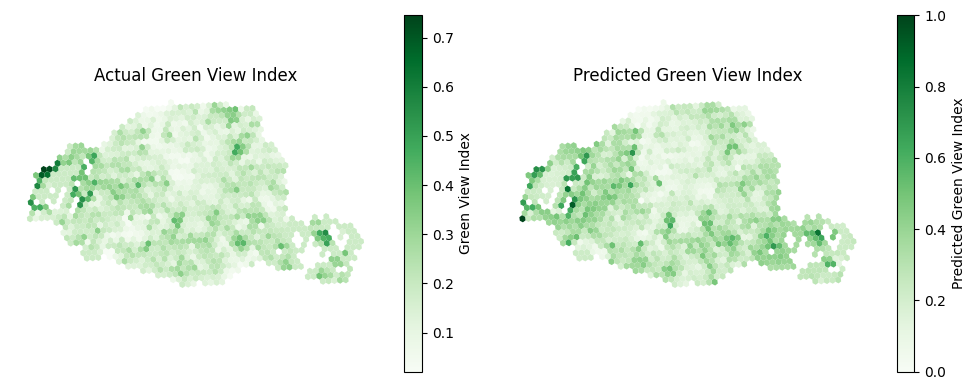

In [9]:
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_performer_only_model.pth', h3_nodes, criterion)

Analyzing correlations between attention heads in Layer 0


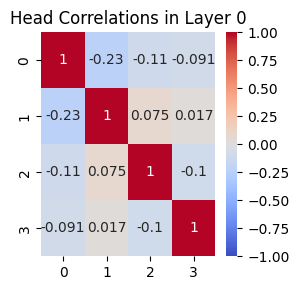

Analyzing correlations between attention heads in Layer 1


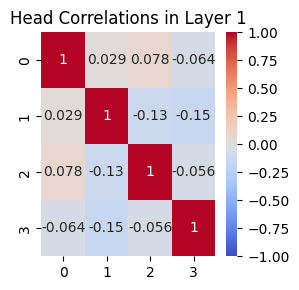

Analyzing correlations between attention heads in Layer 2


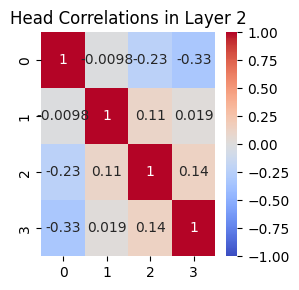

Analyzing correlations between attention heads in Layer 3


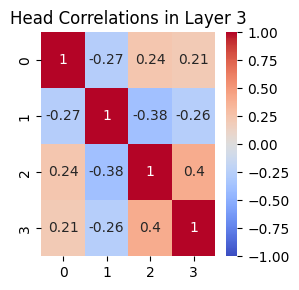

array([[ 1.        , -0.27240648,  0.23697069,  0.20896277],
       [-0.27240648,  1.        , -0.38304136, -0.26140976],
       [ 0.23697069, -0.38304136,  1.        ,  0.3985132 ],
       [ 0.20896277, -0.26140976,  0.3985132 ,  1.        ]])

In [10]:
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=0, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=1, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=2, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=3, model_type='Performer', visualize=True)


torch.Size([1228, 1228])


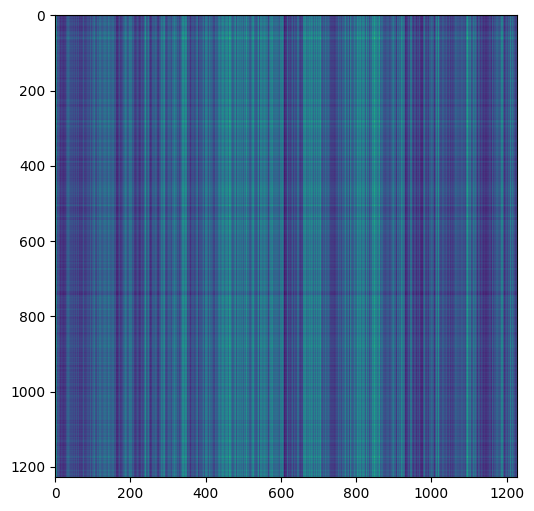

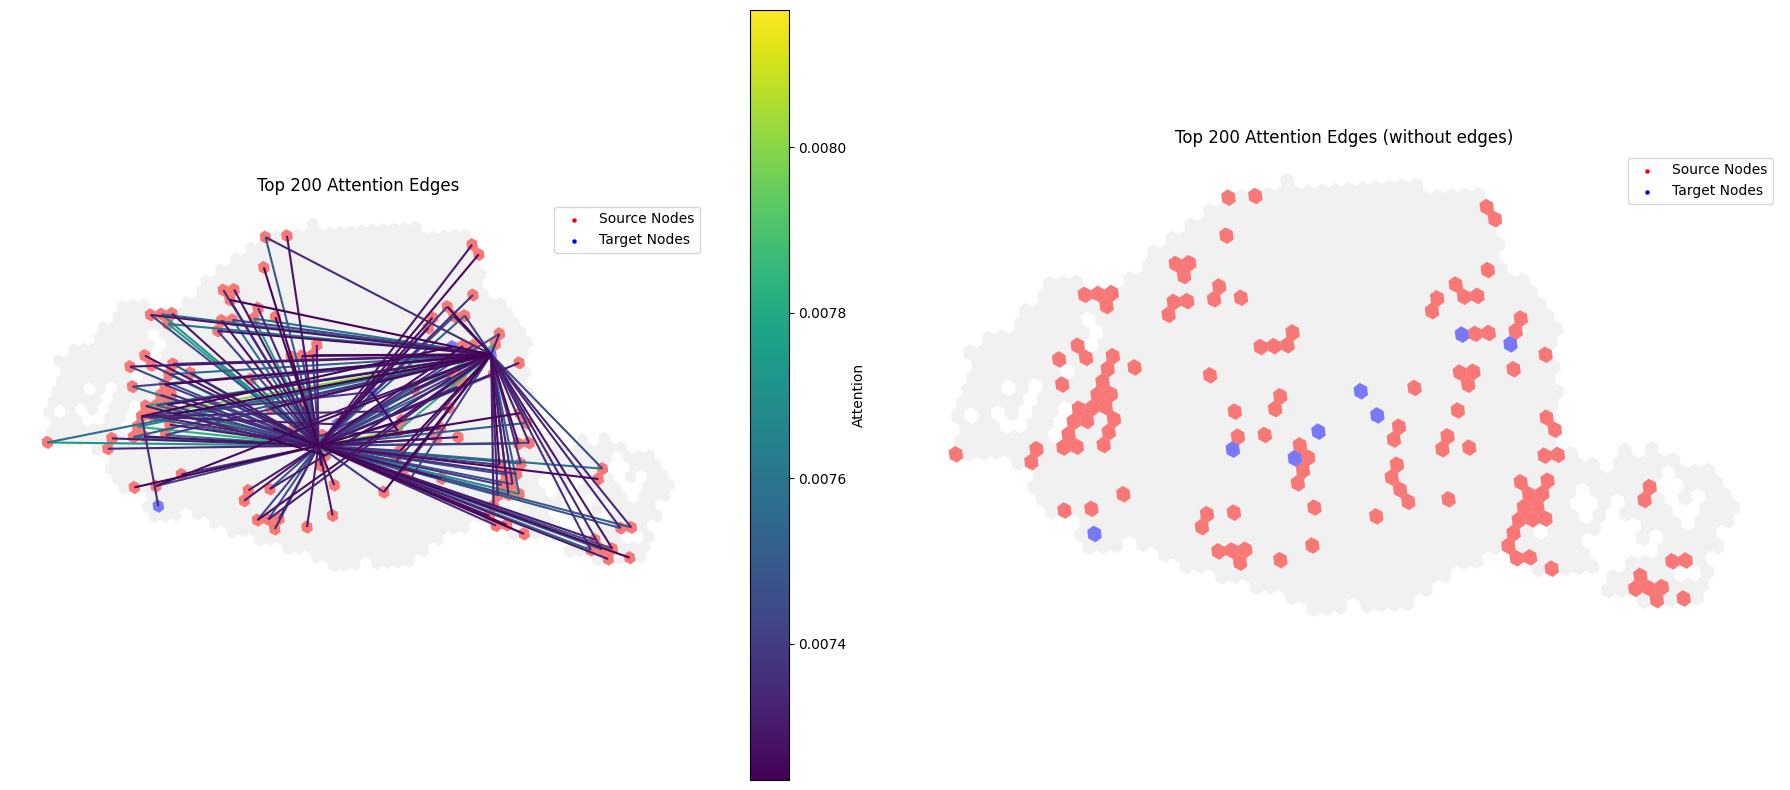

In [11]:
A_flow = make_attention_graph(model, CompleteData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)

f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )


plot_top_k_attention_edges(A_flow.cpu().numpy(), h3_nodes, top_k=200)

Basically we got results that make sense, we see that there are reference nodes once again.

### Repeating everything with basic data

In [12]:
model_basic = PerformerModel(
    in_channels=BasicData.num_features,
    pe_input_dim=BasicData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=4,
    head_channels=16,
    num_layers=4,
    dropout=0.4,
)
model_basic.to(device)
# Test model output shape
assert model_basic(BasicData.x, BasicData.pe, BasicData.edge_index).squeeze().shape == BasicData.y.shape

In [17]:
# Training loop setup
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_basic.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(model_basic, BasicData, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model_basic, BasicData, BasicData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model_basic.state_dict(), 'best_models_paris/best_performer_only_model_basic.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model_basic, BasicData, BasicData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0084, Val Loss: 0.0090, Test Loss: 0.0073
Epoch: 020, Train Loss: 0.0077, Val Loss: 0.0086, Test Loss: 0.0071
Epoch: 030, Train Loss: 0.0072, Val Loss: 0.0077, Test Loss: 0.0063
Epoch: 040, Train Loss: 0.0066, Val Loss: 0.0071, Test Loss: 0.0062
Epoch: 050, Train Loss: 0.0060, Val Loss: 0.0064, Test Loss: 0.0058
Epoch: 060, Train Loss: 0.0062, Val Loss: 0.0069, Test Loss: 0.0059
Epoch: 070, Train Loss: 0.0063, Val Loss: 0.0064, Test Loss: 0.0053
Epoch: 080, Train Loss: 0.0056, Val Loss: 0.0063, Test Loss: 0.0051
Epoch: 090, Train Loss: 0.0066, Val Loss: 0.0071, Test Loss: 0.0055
Epoch: 100, Train Loss: 0.0060, Val Loss: 0.0063, Test Loss: 0.0051
Epoch: 110, Train Loss: 0.0058, Val Loss: 0.0063, Test Loss: 0.0050
Epoch: 120, Train Loss: 0.0061, Val Loss: 0.0069, Test Loss: 0.0055
Epoch: 130, Train Loss: 0.0056, Val Loss: 0.0059, Test Loss: 0.0053
Epoch: 140, Train Loss: 0.0054, Val Loss: 0.0055, Test Loss: 0.0051
Epoch: 150, Train Lo

Final Test Results - Loss: 0.0056


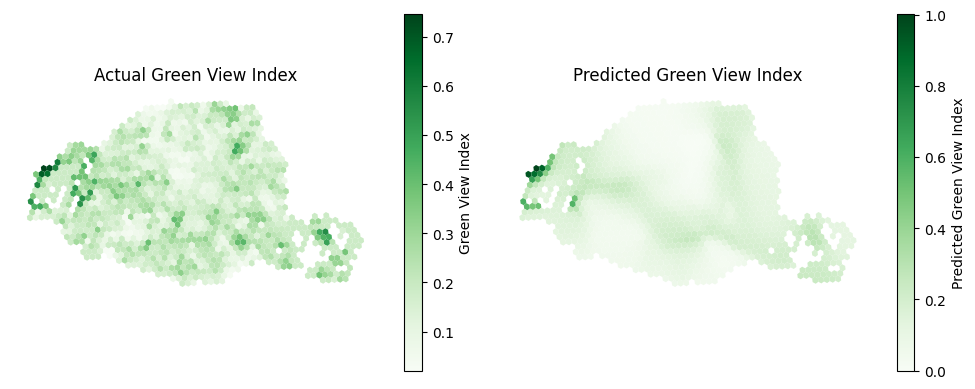

In [18]:
evaluate_and_visualize_predictions(model_basic, BasicData, 'best_models_paris/best_performer_only_model_basic.pth', h3_nodes, criterion)

torch.Size([1228, 1228])


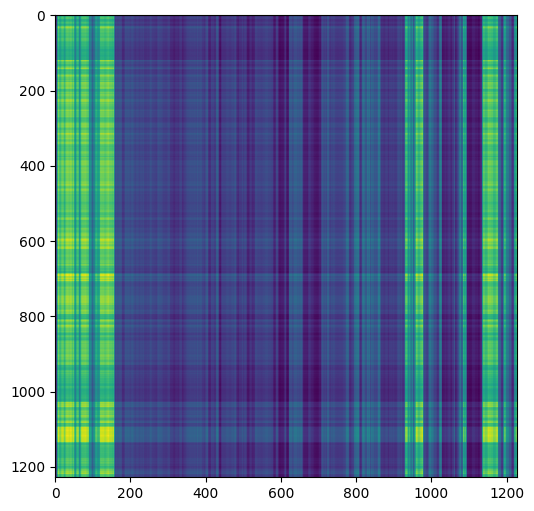

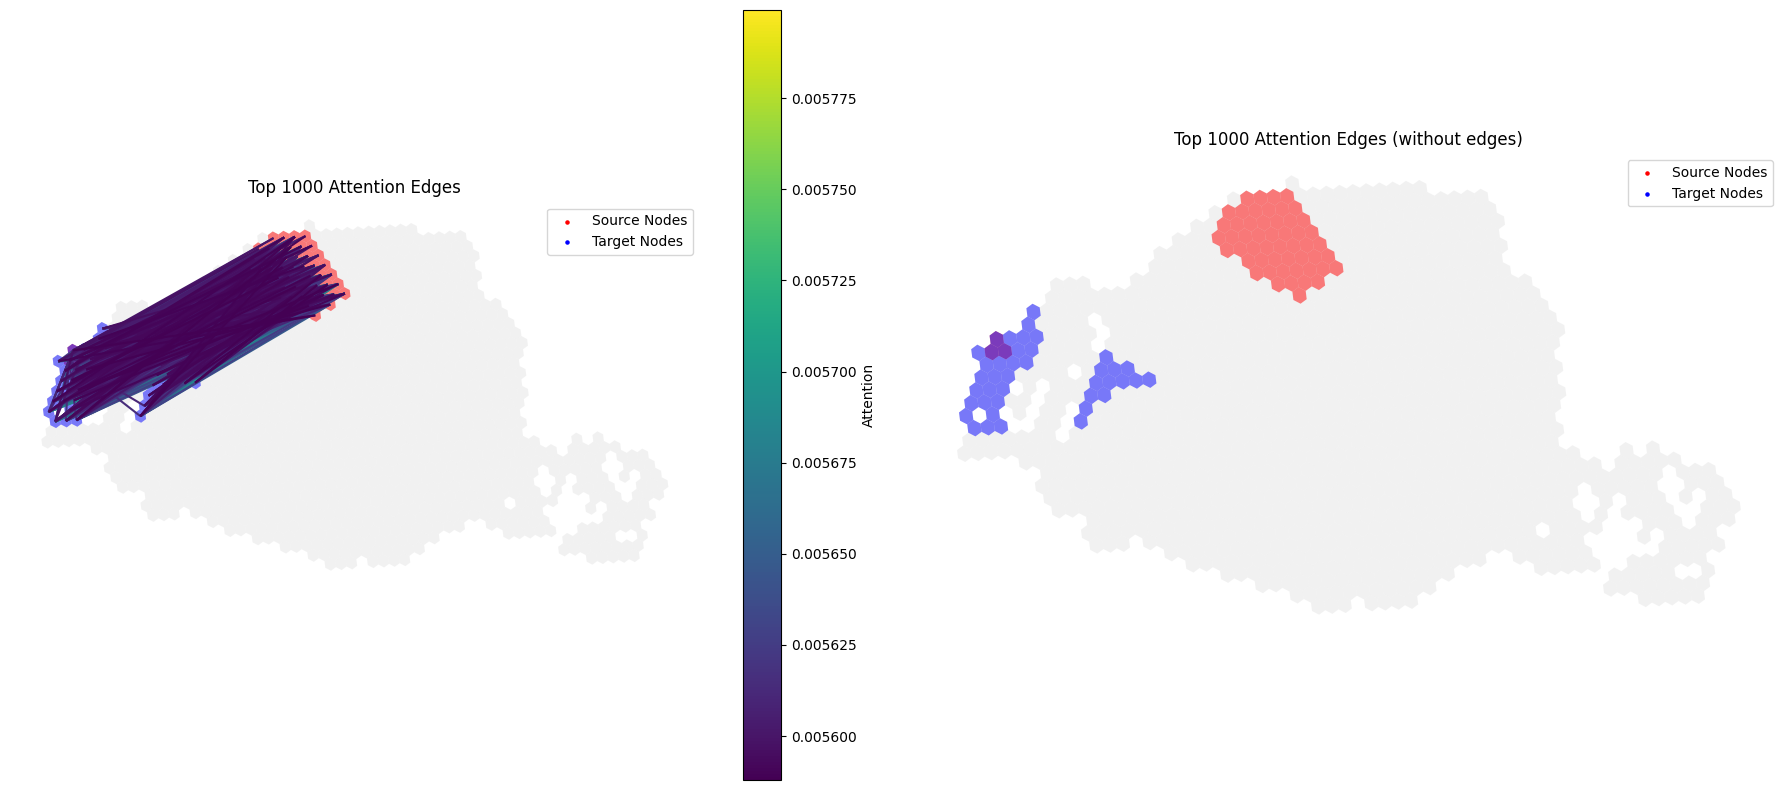

In [19]:
A_flow = make_attention_graph(model_basic, BasicData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)
f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )
plot_top_k_attention_edges(A_flow.cpu().numpy(), h3_nodes, top_k=1000)

# Hybrid models
## GPS - like model

In [20]:
class HybridModelv2(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_layers: int = 3,
        dropout: float = 0.4,
        combine_method: str = 'sum',  # 'sum', 'concat'
    ):
        super().__init__()
        
        # Input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)

        # GPS layers
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # Transformer component
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                
                # GAT component
                'gat': GATv2Conv(hidden_channels, hidden_channels // heads, 
                               heads=heads, concat=True, dropout=dropout),

                # Normalization
                'trans_norm': nn.LayerNorm(hidden_channels),
                'gat_norm': nn.LayerNorm(hidden_channels),
                
                # Combination method
                'combine': self._make_combiner(combine_method, hidden_channels),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.layers.append(layer)
        
        # Output layer for edge prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def _make_combiner(self, method, hidden_channels):
        if method == 'sum':
            return nn.Identity()
        elif method == 'concat':
            return nn.Sequential(
                nn.Linear(hidden_channels * 2, hidden_channels),
                nn.ReLU()
            )
        
    
    def forward(self, x, pe, edge_index, batch=None):
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        # Process through GPS layers
        for layer in self.layers:
            # Pre-normalization
            x_norm = layer['norm'](x)
            
            # Transformer component
            x_trans = x_norm.unsqueeze(0)
            x_trans = layer['attention'](x_trans).squeeze(0)
            x_trans = layer['trans_norm'](x_trans)
            
            
            # GAT component
            x_gat = layer['gat'](x_norm, edge_index)
            x_gat = layer['gat_norm'](x_gat)
            
            
            # Combine the outputs with residual connection
            if isinstance(layer['combine'], nn.Identity):  # Sum
                x_combined = x_trans + x_gat + x  # Residual
            elif isinstance(layer['combine'], nn.Sequential):  # Concat
                x_combined = layer['combine'](torch.cat([x_trans, x_gat], dim=1)) + x
            
            # Feed-forward network with residual
            x = x_combined + layer['ffn'](x_combined)

        
        return self.output_layer(x)
    
       

    def get_performer_attention(self, x, pe, edge_index, layer_idx=0, mask=None):
        """Extract the attention approximation used by Performer for a specific layer.
        
        Makes more sense to use this method for interpretability once the model is trained.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            mask: Optional mask
            
        Returns:
            Tensor of shape [heads, num_nodes, num_nodes] representing attention weights
        """
        if layer_idx < 0 or layer_idx >= len(self.layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            
            # Process through previous layers
            for i in range(layer_idx):
                layer = self.layers[i]
                # Pre-normalization
                x_norm = layer['norm'](x)
                
                # Transformer component
                x_trans = x_norm.unsqueeze(0)
                x_trans = layer['attention'](x_trans).squeeze(0)
                x_trans = layer['trans_norm'](x_trans)
                
                # GAT component
                x_gat = layer['gat'](x_norm, edge_index)
                x_gat = layer['gat_norm'](x_gat)
                
                # Combine the outputs with residual connection
                if isinstance(layer['combine'], nn.Identity):  # Sum
                    x_combined = x_trans + x_gat + x  # Residual
                elif isinstance(layer['combine'], nn.Sequential):  # Concat
                    x_combined = layer['combine'](torch.cat([x_trans, x_gat], dim=1)) + x
                
                # Feed-forward network with residual
                x = x_combined + layer['ffn'](x_combined)
            
            # Now x contains the input to the target layer
            # Get the target layer
            layer = self.layers[layer_idx]
            
            # Apply layer norm
            x_norm = layer['norm'](x)
            
            # Add batch dimension for attention
            x = x_norm.unsqueeze(0)
            
            # Get Q, K, V projections
            attention = layer['attention']
            B, N, C = x.shape
            q, k, v = attention.q(x), attention.k(x), attention.v(x)
            
            # Reshape to multi-head format
            q, k, v = map(
                lambda t: t.reshape(B, N, attention.heads, attention.head_channels).permute(
                    0, 2, 1, 3), (q, k, v))
            
            # Apply the kernel approximation to q and k
            fast_attn = attention.fast_attn
            q_prime = generalized_kernel(q, fast_attn.projection_matrix, fast_attn.kernel)
            k_prime = generalized_kernel(k, fast_attn.projection_matrix, fast_attn.kernel)
            
            # Compute approximate attention matrix
            # This is analogous to softmax(QK^T) in standard attention
            k_prime_sum = k_prime.sum(dim=-2, keepdim=True)  # Sum over nodes
            
            # For explicit attention weights (inefficient but interpretable)
            attention_weights = []
            for h in range(attention.heads):
                head_q = q_prime[0, h]  # [N, features]
                head_k = k_prime[0, h]  # [N, features]
                
                # Compute normalized attention (shape: [N, N])
                attn_mat = torch.zeros(N, N, device=q.device)
                for i in range(N):
                    q_i = head_q[i:i+1]  # [1, features]
                    # Normalized kernel dot product for each node pair
                    attn_i = (q_i @ head_k.transpose(-1, -2)) / (q_i @ k_prime_sum[0, h].transpose(-1, -2))
                    attn_mat[i] = attn_i
                
                attention_weights.append(attn_mat)
            
            return torch.stack(attention_weights)  # [heads, N, N]

    def get_attention_weights(self, x, pe, edge_index, layer_idx=0, mask=None):
        """Extract the attention weights from GATv2Conv for a specific layer.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            mask: Optional mask
            
        Returns:
            Tuple of (edge_index, attention_weights) where attention_weights has
            shape [num_edges+nodes, heads]
        """
        if layer_idx < 0 or layer_idx >= len(self.layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            
            # Process through previous layers
            for i in range(layer_idx):
                layer = self.layers[i]
                # Pre-normalization
                x_norm = layer['norm'](x)
                
                # Transformer component
                x_trans = x_norm.unsqueeze(0)
                x_trans = layer['attention'](x_trans).squeeze(0)
                x_trans = layer['trans_norm'](x_trans)
                
                # GAT component
                x_gat = layer['gat'](x_norm, edge_index)
                x_gat = layer['gat_norm'](x_gat)
                
                # Combine the outputs with residual connection
                if isinstance(layer['combine'], nn.Identity):  # Sum
                    x_combined = x_trans + x_gat + x  # Residual
                elif isinstance(layer['combine'], nn.Sequential):  # Concat
                    x_combined = layer['combine'](torch.cat([x_trans, x_gat], dim=1)) + x
                
                # Feed-forward network with residual
                x = x_combined + layer['ffn'](x_combined)
            
            # Get the target layer
            layer = self.layers[layer_idx]
            x_norm = layer['norm'](x)
            
            # Return the edge_index and attention weights
            # For GATv2Conv, we use return_attention_weights=True to get attention weights
            _, (att_edge_ind, attention_weights) = layer['gat'](x_norm, edge_index, return_attention_weights=True)
            
            # The attention weights will have shape [num_edges, heads]
            return att_edge_ind, attention_weights

    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.layers:
            layer['attention'].redraw_projection_matrix()


model = HybridModelv2(
    in_channels=CompleteData.num_features,
    pe_input_dim=CompleteData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)

assert model(CompleteData.x, CompleteData.pe, CompleteData.edge_index).squeeze().shape == CompleteData.y.shape, "Model output shape does not match target shape"

In [21]:
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(model, CompleteData, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model, CompleteData, CompleteData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_models_paris/best_hybridv2_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model, CompleteData, CompleteData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0329, Val Loss: 0.0111, Test Loss: 0.0117
Epoch: 020, Train Loss: 0.0121, Val Loss: 0.0066, Test Loss: 0.0072
Epoch: 030, Train Loss: 0.0094, Val Loss: 0.0060, Test Loss: 0.0068
Epoch: 040, Train Loss: 0.0085, Val Loss: 0.0059, Test Loss: 0.0065
Epoch: 050, Train Loss: 0.0086, Val Loss: 0.0055, Test Loss: 0.0063
Epoch: 060, Train Loss: 0.0078, Val Loss: 0.0053, Test Loss: 0.0061
Epoch: 070, Train Loss: 0.0075, Val Loss: 0.0052, Test Loss: 0.0059
Epoch: 080, Train Loss: 0.0077, Val Loss: 0.0051, Test Loss: 0.0059
Epoch: 090, Train Loss: 0.0070, Val Loss: 0.0052, Test Loss: 0.0059
Epoch: 100, Train Loss: 0.0075, Val Loss: 0.0052, Test Loss: 0.0058
Epoch: 110, Train Loss: 0.0075, Val Loss: 0.0050, Test Loss: 0.0057
Epoch: 120, Train Loss: 0.0072, Val Loss: 0.0050, Test Loss: 0.0057
Epoch: 130, Train Loss: 0.0067, Val Loss: 0.0051, Test Loss: 0.0056
Epoch: 140, Train Loss: 0.0065, Val Loss: 0.0049, Test Loss: 0.0055
Epoch: 150, Train Lo

### Attention Graph computation and visualization

Final Test Results - Loss: 0.0035


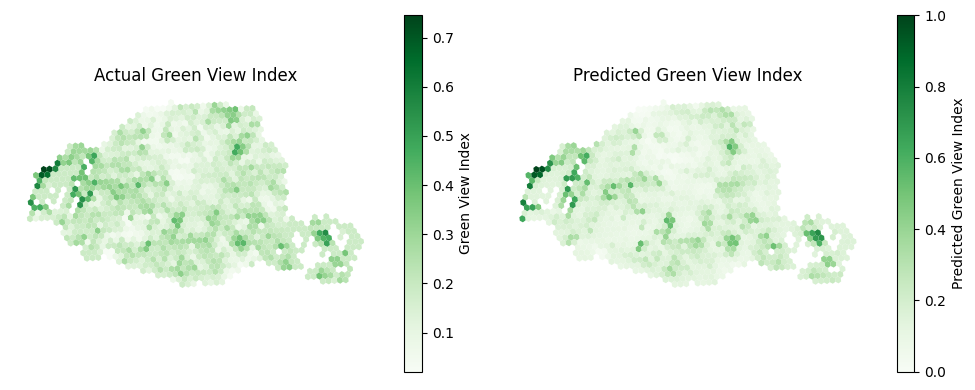

In [23]:
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_hybridv2_model.pth', h3_nodes, criterion)

Correlation analysis for Performer part
Analyzing correlations between attention heads in Layer 0


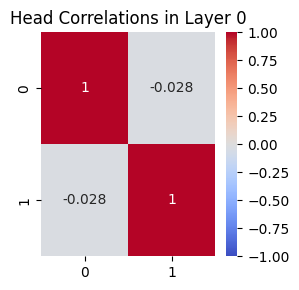

Analyzing correlations between attention heads in Layer 1


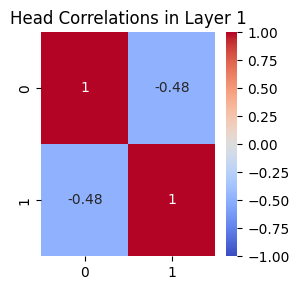

Analyzing correlations between attention heads in Layer 2


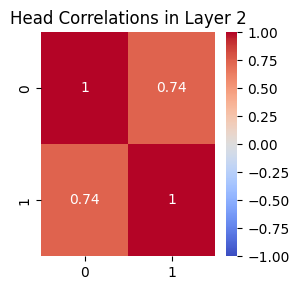

Analyzing correlations between attention heads in Layer 3


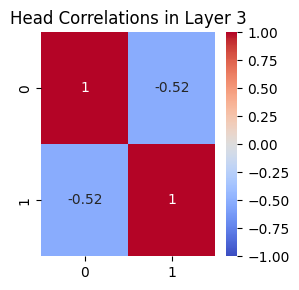

Correlation analysis for GATv2 part
Analyzing correlations between attention heads in Layer 0


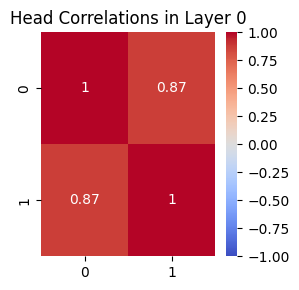

Analyzing correlations between attention heads in Layer 1


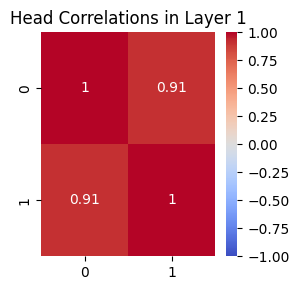

Analyzing correlations between attention heads in Layer 2


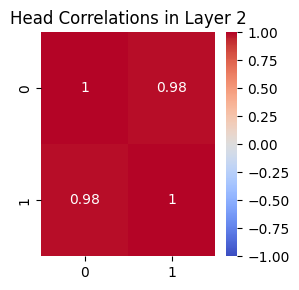

Analyzing correlations between attention heads in Layer 3


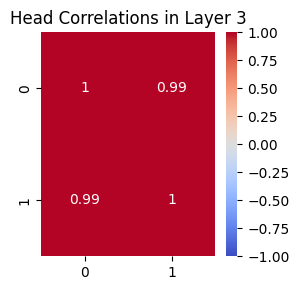

array([[1.        , 0.99443103],
       [0.99443103, 1.        ]])

In [24]:
print("Correlation analysis for Performer part")
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=0, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=1, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=2, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=3, model_type='Performer', visualize=True)

print("Correlation analysis for GATv2 part")
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=0, model_type='GATv2', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=1, model_type='GATv2', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=2, model_type='GATv2', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=3, model_type='GATv2', visualize=True)


torch.Size([1228, 1228])


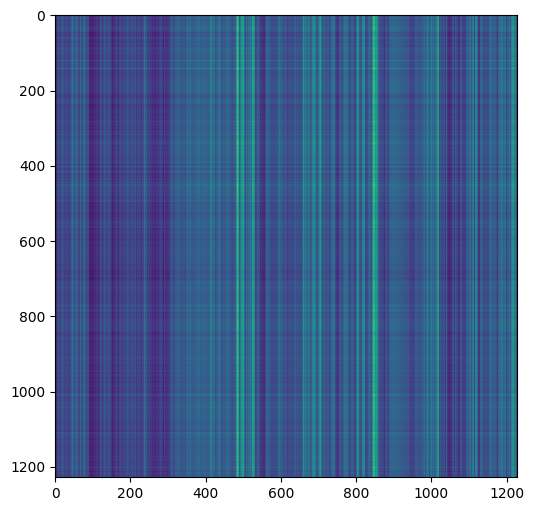

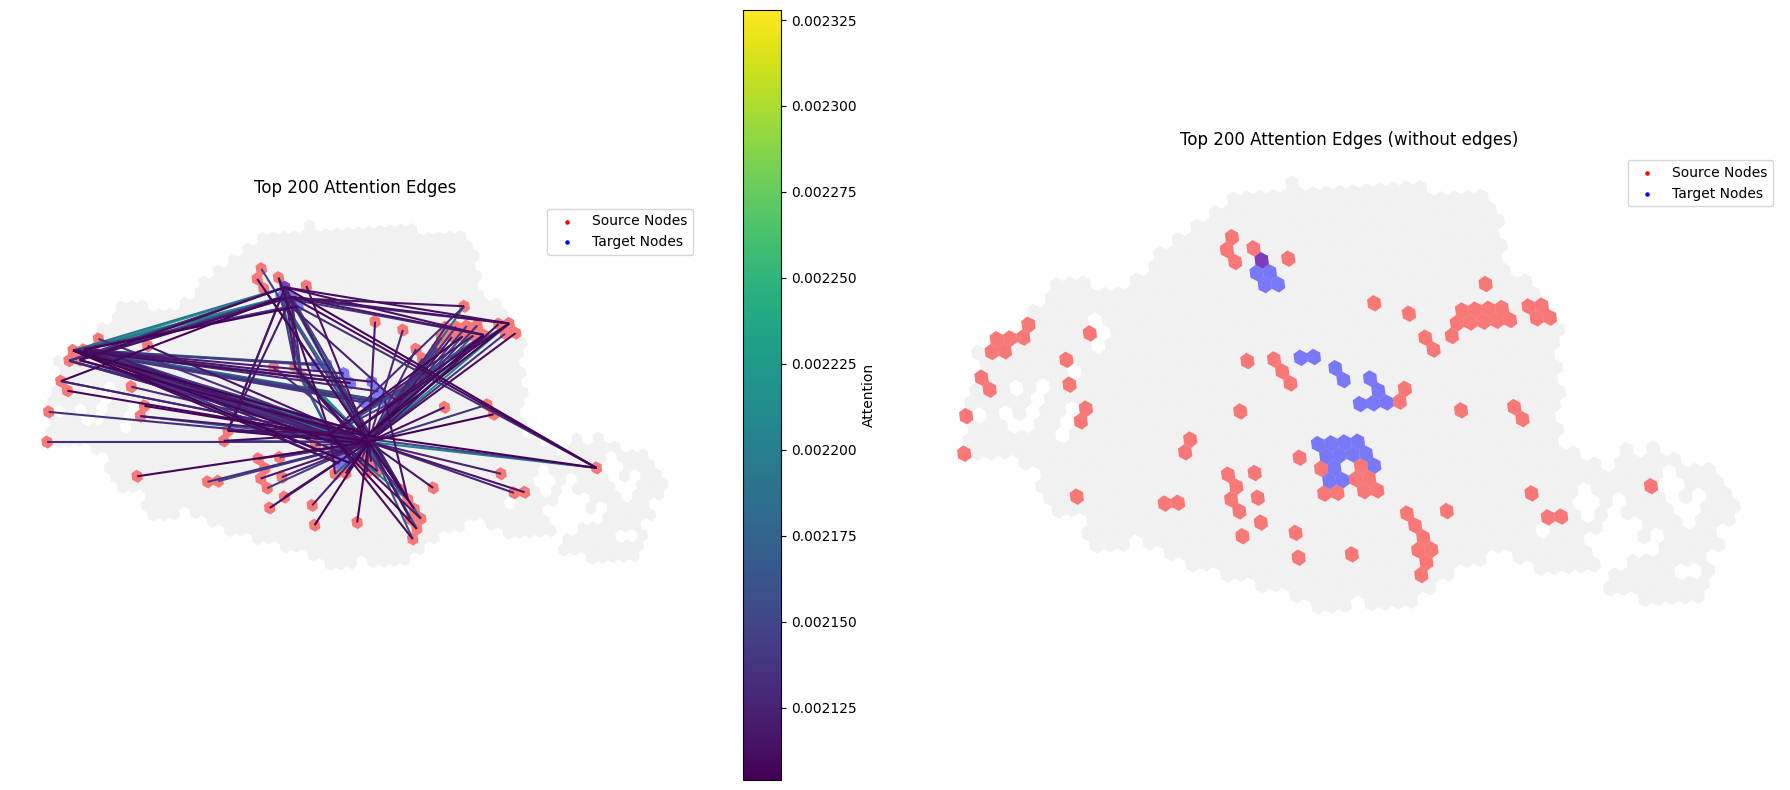

In [25]:
A_flow = make_attention_graph(model, CompleteData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)
f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )
plot_top_k_attention_edges(A_flow.cpu().numpy(), h3_nodes, top_k=200)

### Repeating everything with basic data

In [26]:
model_basic = HybridModelv2(
    in_channels=BasicData.num_features,
    pe_input_dim=BasicData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model_basic.to(device)

assert model_basic(BasicData.x, BasicData.pe, BasicData.edge_index).squeeze().shape == BasicData.y.shape, "Model output shape does not match target shape"

In [27]:
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_basic.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(model_basic, BasicData, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model_basic, BasicData, BasicData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model_basic.state_dict(), 'best_models_paris/best_hybridv2_model_basic.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model_basic, BasicData, BasicData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, Counter: {early_stop_counter}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.1920, Val Loss: 0.1169, Test Loss: 0.1204, Counter: 4
Epoch: 020, Train Loss: 0.0425, Val Loss: 0.0138, Test Loss: 0.0105, Counter: 3
Epoch: 030, Train Loss: 0.0237, Val Loss: 0.0131, Test Loss: 0.0099, Counter: 13
Epoch: 040, Train Loss: 0.0219, Val Loss: 0.0096, Test Loss: 0.0070, Counter: 0
Epoch: 050, Train Loss: 0.0168, Val Loss: 0.0094, Test Loss: 0.0070, Counter: 5
Epoch: 060, Train Loss: 0.0179, Val Loss: 0.0095, Test Loss: 0.0071, Counter: 15
Epoch: 070, Train Loss: 0.0158, Val Loss: 0.0090, Test Loss: 0.0067, Counter: 1
Epoch: 080, Train Loss: 0.0158, Val Loss: 0.0089, Test Loss: 0.0066, Counter: 0
Epoch: 090, Train Loss: 0.0132, Val Loss: 0.0086, Test Loss: 0.0064, Counter: 2
Epoch: 100, Train Loss: 0.0144, Val Loss: 0.0084, Test Loss: 0.0063, Counter: 1
Epoch: 110, Train Loss: 0.0136, Val Loss: 0.0085, Test Loss: 0.0063, Counter: 4
Epoch: 120, Train Loss: 0.0134, Val Loss: 0.0084, Test Loss: 0.0063, Counter: 2
Epoch: 130

Final Test Results - Loss: 0.0060


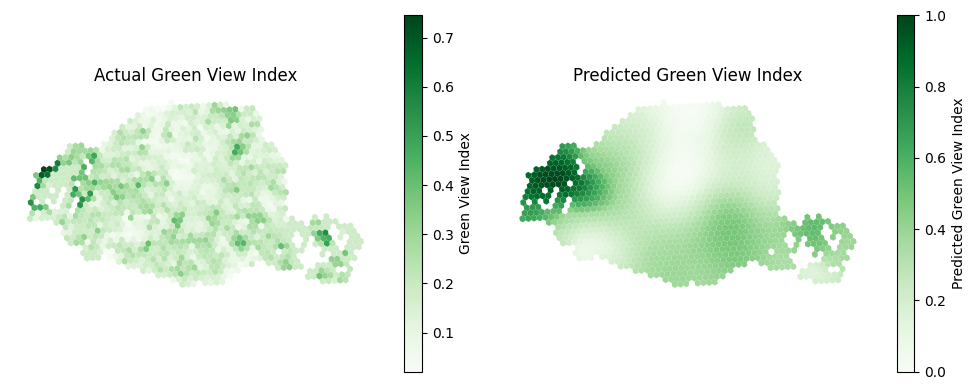

In [29]:
evaluate_and_visualize_predictions(model_basic, BasicData, 'best_models_paris/best_hybridv2_model_basic.pth', h3_nodes, criterion)

torch.Size([1228, 1228])


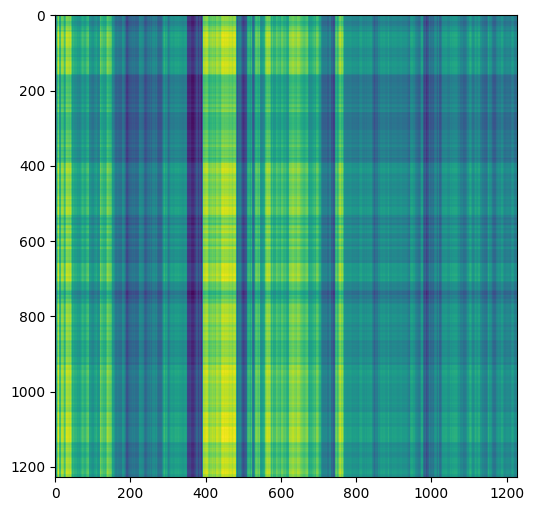

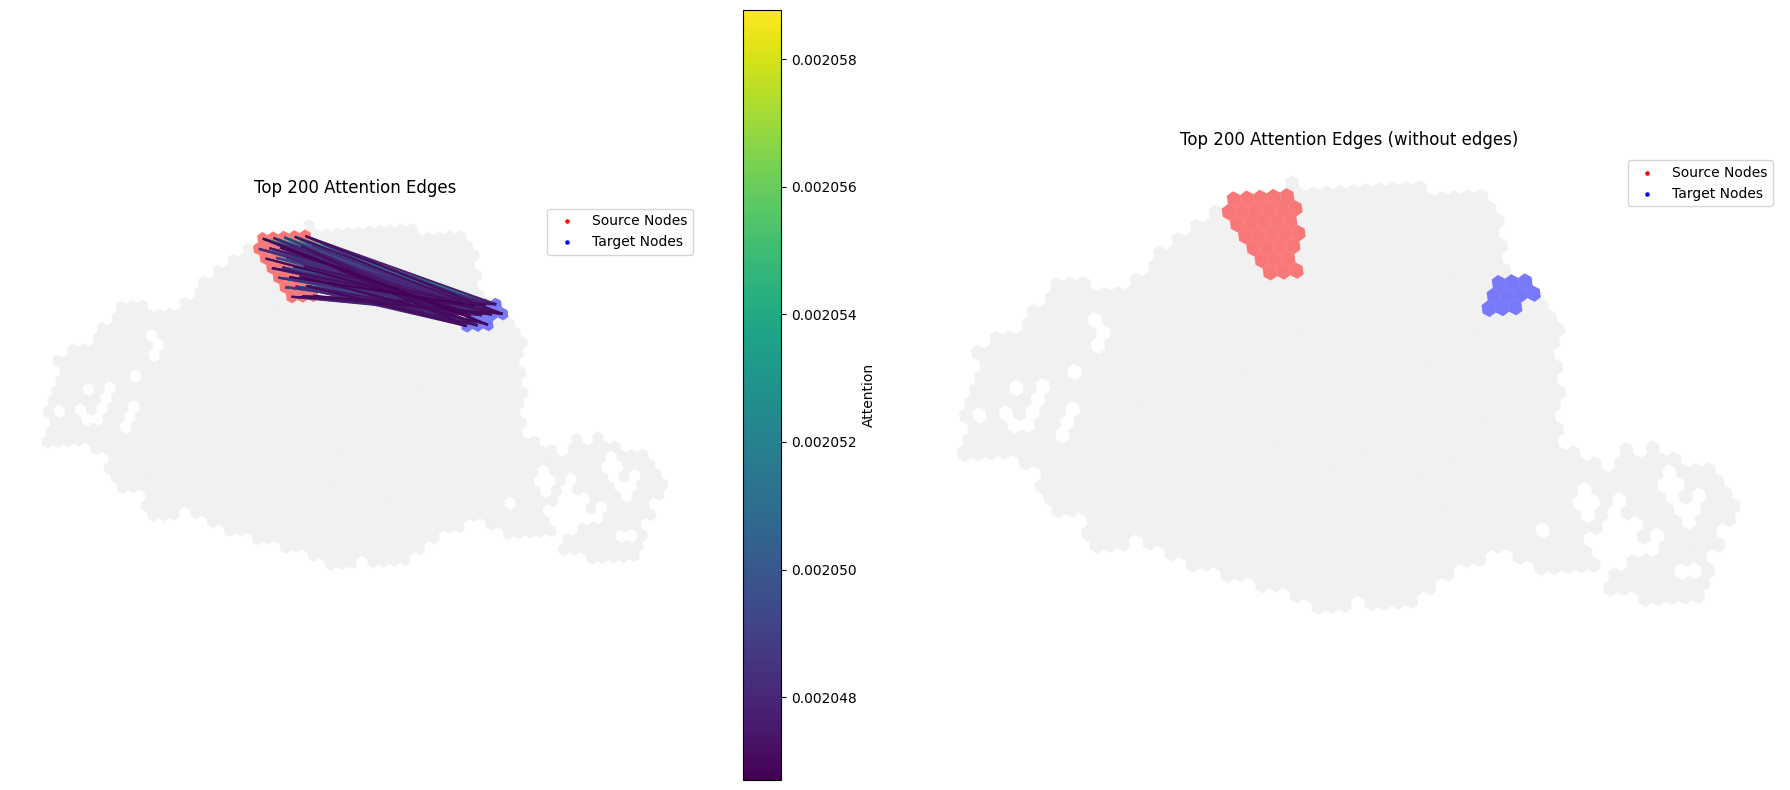

In [30]:
A_flow = make_attention_graph(model_basic, BasicData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)
f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )
plot_top_k_attention_edges(A_flow.cpu().numpy(), h3_nodes, top_k=200)

## Independent GAT - Perf model

In [7]:
class HybridModel_variant(nn.Module):
    def __init__(
        self,
        in_channels: int,
        pe_input_dim: int,
        pe_dim: int,
        hidden_channels: int,
        heads: int,
        head_channels: int,
        num_transformer_layers: int = 2,
        num_gat_layers: int = 2,
        dropout: float = 0.4,
        combine_method: str = 'concat',  # 'concat', 'sum'
    ):
        super().__init__()
        
        # Shared input embedding
        self.node_emb = nn.Linear(in_channels, hidden_channels - pe_dim)
        self.pe_lin = nn.Linear(pe_input_dim, pe_dim)
        self.pe_norm = nn.BatchNorm1d(pe_input_dim)
        
        # Transformer branch (DeepGraphPerformer)
        self.transformer_layers = nn.ModuleList()
        for _ in range(num_transformer_layers):
            layer = nn.ModuleDict({
                'norm1': nn.LayerNorm(hidden_channels),
                'attention': PerformerAttention(
                    channels=hidden_channels,
                    heads=heads,
                    head_channels=head_channels,
                    kernel=torch.nn.ReLU(),
                    dropout=dropout
                ),
                'norm2': nn.LayerNorm(hidden_channels),
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.transformer_layers.append(layer)
        
        # GAT branch - improved with proper normalization and FFN
        self.gat_layers = nn.ModuleList()
        for _ in range(num_gat_layers):
            layer = nn.ModuleDict({
                # Pre-normalization
                'norm': nn.LayerNorm(hidden_channels),
                
                # GAT component
                'gat': GATv2Conv(
                    hidden_channels, 
                    hidden_channels, 
                    heads=heads, 
                    concat=True, 
                    dropout=dropout
                ),
                
                # Post-normalization
                'gat_norm': nn.LayerNorm(hidden_channels*heads),
                
                # Feed-forward network
                'ffn': nn.Sequential(
                    nn.Linear(hidden_channels*heads, hidden_channels*2),
                    nn.Dropout(dropout),
                    nn.ReLU(),
                    nn.Linear(hidden_channels*2, hidden_channels)
                )
            })
            self.gat_layers.append(layer)
        
        # Layer normalization for transformer and GAT outputs before combining
        self.transformer_norm = nn.LayerNorm(hidden_channels)
        self.gat_norm = nn.LayerNorm(hidden_channels)
        
        # Combination method
        self.combine_method = combine_method
        if combine_method == 'concat':
            self.combine = nn.Linear(hidden_channels * 2, hidden_channels)
        
        # Output layer for node prediction
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, 1)
        )
    
    def forward(self, x, pe, edge_index, branch='both'):
        """
        Forward pass with option to use specific branches.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            branch: Which branch to use ('both', 'gat', or 'performer')
        """
        # Initial embedding
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        
        if branch in ['both', 'performer']:
            # Transformer branch
            transformer_x = x
            for layer in self.transformer_layers:
                # Attention block with residual
                residual = transformer_x
                transformer_x_norm = layer['norm1'](transformer_x)
                transformer_x_attn = transformer_x_norm.unsqueeze(0)
                transformer_x_attn = layer['attention'](transformer_x_attn)
                transformer_x = transformer_x_attn.squeeze(0) + residual
                
                # FFN block with residual
                residual = transformer_x
                transformer_x = layer['norm2'](transformer_x)
                transformer_x = layer['ffn'](transformer_x) + residual
            
            transformer_x = self.transformer_norm(transformer_x)
        
        if branch in ['both', 'gat']:
            # GAT branch - improved with proper residuals and FFN
            gat_x = x
            for layer in self.gat_layers:
                # Pre-normalization
                gat_x_norm = layer['norm'](gat_x)
                
                # Apply GAT 
                gat_x_attn = layer['gat'](gat_x_norm, edge_index)
                gat_x_attn = layer['gat_norm'](gat_x_attn)
                
                # Apply FFN with residual
                gat_x_ff = layer['ffn'](gat_x_attn)
                
                # Add residual connection from before GAT (matches GAT_model design)
                gat_x = gat_x + gat_x_ff
            
            gat_x = self.gat_norm(gat_x)
        
        # Combine or use individual branch based on parameter
        if branch == 'both':
            if self.combine_method == 'sum':
                combined_x = transformer_x + gat_x
            elif self.combine_method == 'concat':
                combined_x = torch.cat([transformer_x, gat_x], dim=1)
                combined_x = F.relu(self.combine(combined_x))
        elif branch == 'performer':
            combined_x = transformer_x
        elif branch == 'gat':
            combined_x = gat_x
        
        # Final prediction
        return self.output_layer(combined_x)
    
    def redraw_projection_matrix(self):
        """Redraw projection matrices in all attention layers."""
        for layer in self.transformer_layers:
            attention = layer['attention']
            attention.redraw_projection_matrix()
    
    def get_performer_attention(self, x, pe, edge_index, layer_idx=0, mask=None):
        """Extract the attention approximation used by Performer for a specific layer.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            mask: Optional mask
            
        Returns:
            Tensor of shape [heads, num_nodes, num_nodes] representing attention weights
        """
        if layer_idx < 0 or layer_idx >= len(self.transformer_layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.transformer_layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            transformer_x = x
            
            # Process through previous transformer layers
            for i in range(layer_idx):
                layer = self.transformer_layers[i]
                # Attention block with residual
                residual = transformer_x
                transformer_x_norm = layer['norm1'](transformer_x)
                transformer_x_attn = transformer_x_norm.unsqueeze(0)
                transformer_x_attn = layer['attention'](transformer_x_attn)
                transformer_x = transformer_x_attn.squeeze(0) + residual
                
                # FFN block with residual
                residual = transformer_x
                transformer_x = layer['norm2'](transformer_x)
                transformer_x = layer['ffn'](transformer_x) + residual
            
            # Get the target layer
            layer = self.transformer_layers[layer_idx]
            transformer_x_norm = layer['norm1'](transformer_x)
            
            # Add batch dimension for attention
            x = transformer_x_norm.unsqueeze(0)
            
            # Get Q, K, V projections
            attention = layer['attention']
            B, N, C = x.shape
            q, k, v = attention.q(x), attention.k(x), attention.v(x)
            
            # Reshape to multi-head format
            q, k, v = map(
                lambda t: t.reshape(B, N, attention.heads, attention.head_channels).permute(
                    0, 2, 1, 3), (q, k, v))
            
            # Apply the kernel approximation to q and k
            fast_attn = attention.fast_attn
            q_prime = generalized_kernel(q, fast_attn.projection_matrix, fast_attn.kernel)
            k_prime = generalized_kernel(k, fast_attn.projection_matrix, fast_attn.kernel)
            
            # Compute approximate attention matrix
            k_prime_sum = k_prime.sum(dim=-2, keepdim=True)
            
            # For explicit attention weights
            attention_weights = []
            for h in range(attention.heads):
                head_q = q_prime[0, h]  # [N, features]
                head_k = k_prime[0, h]  # [N, features]
                
                # Compute normalized attention (shape: [N, N])
                attn_mat = torch.zeros(N, N, device=q.device)
                for i in range(N):
                    q_i = head_q[i:i+1]  # [1, features]
                    # Normalized kernel dot product for each node pair
                    attn_i = (q_i @ head_k.transpose(-1, -2)) / (q_i @ k_prime_sum[0, h].transpose(-1, -2))
                    attn_mat[i] = attn_i
                
                attention_weights.append(attn_mat)
            
            return torch.stack(attention_weights)  # [heads, N, N]
    
    def get_attention_weights(self, x, pe, edge_index, layer_idx=0):
        """Extract the attention weights from GATv2Conv for a specific layer.
        
        Args:
            x: Node features
            pe: Positional encoding
            edge_index: Graph connectivity
            layer_idx: Index of the layer to extract attention from (default: 0)
            
        Returns:
            Tuple of (edge_index, attention_weights) where attention_weights has
            shape [num_edges, heads]
        """
        if layer_idx < 0 or layer_idx >= len(self.gat_layers):
            raise ValueError(f"Layer index {layer_idx} out of range (0-{len(self.gat_layers)-1})")
        
        self.eval()
        with torch.no_grad():
            # Initial embedding
            x_pe = self.pe_norm(pe)
            x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
            gat_x = x
            
            # Process through previous layers using the proper GAT layer structure
            for i in range(layer_idx):
                layer = self.gat_layers[i]
                # Pre-normalization
                gat_x_norm = layer['norm'](gat_x)
                
                # Apply GAT 
                gat_x_attn = layer['gat'](gat_x_norm, edge_index)
                gat_x_attn = layer['gat_norm'](gat_x_attn)
                
                # Apply FFN with residual
                gat_x_ff = layer['ffn'](gat_x_attn)
                
                # Add residual connection from before GAT
                gat_x = gat_x + gat_x_ff
            
            # Get the target layer
            layer = self.gat_layers[layer_idx]
            gat_x_norm = layer['norm'](gat_x)
            
            # Return the edge_index and attention weights for the target layer
            # For GATv2Conv, we need to use return_attention_weights=True
            _, (att_edge_ind, attention_weights) = layer['gat'](
                gat_x_norm, edge_index, return_attention_weights=True)
            
            # The attention weights will have shape [num_edges, heads]
            return att_edge_ind, attention_weights
        

# Initialize the model
model = HybridModel_variant(
    in_channels=CompleteData.num_features,
    pe_input_dim=CompleteData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)
assert model(CompleteData.x, CompleteData.pe, CompleteData.edge_index).squeeze().shape == BasicData.y.shape, "Model output shape does not match target shape"

In [8]:
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(model, CompleteData, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model, CompleteData, CompleteData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_models_paris/best_hybrid_variant_model.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model, CompleteData, CompleteData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0333, Val Loss: 0.0116, Test Loss: 0.0135
Epoch: 020, Train Loss: 0.0120, Val Loss: 0.0059, Test Loss: 0.0069
Epoch: 030, Train Loss: 0.0092, Val Loss: 0.0058, Test Loss: 0.0065
Epoch: 040, Train Loss: 0.0088, Val Loss: 0.0051, Test Loss: 0.0058
Epoch: 050, Train Loss: 0.0084, Val Loss: 0.0050, Test Loss: 0.0058
Epoch: 060, Train Loss: 0.0081, Val Loss: 0.0046, Test Loss: 0.0054
Epoch: 070, Train Loss: 0.0071, Val Loss: 0.0044, Test Loss: 0.0052
Epoch: 080, Train Loss: 0.0073, Val Loss: 0.0040, Test Loss: 0.0050
Epoch: 090, Train Loss: 0.0067, Val Loss: 0.0037, Test Loss: 0.0047
Epoch: 100, Train Loss: 0.0063, Val Loss: 0.0036, Test Loss: 0.0046
Epoch: 110, Train Loss: 0.0056, Val Loss: 0.0033, Test Loss: 0.0045
Epoch: 120, Train Loss: 0.0056, Val Loss: 0.0033, Test Loss: 0.0045
Epoch: 130, Train Loss: 0.0055, Val Loss: 0.0032, Test Loss: 0.0044
Epoch: 140, Train Loss: 0.0049, Val Loss: 0.0030, Test Loss: 0.0042
Epoch: 150, Train Lo

### Attention Graph computation and visualization

Final Test Results - Loss: 0.0036


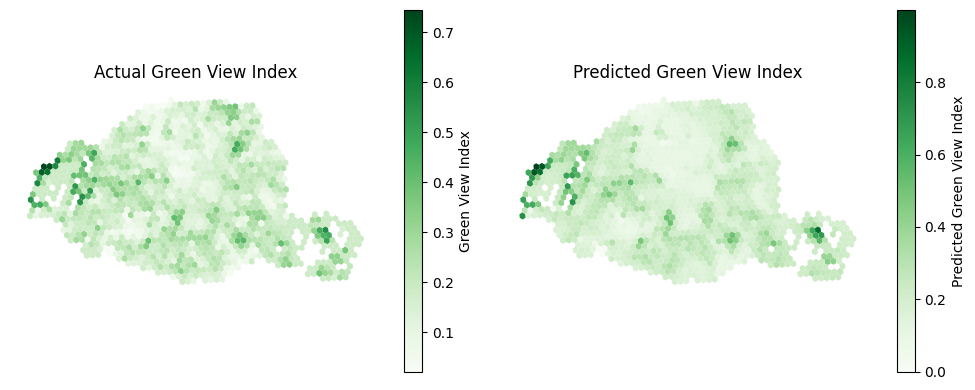

In [9]:
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_hybrid_variant_model.pth', h3_nodes, criterion)

Correlation analysis for Performer part
Analyzing correlations between attention heads in Layer 0


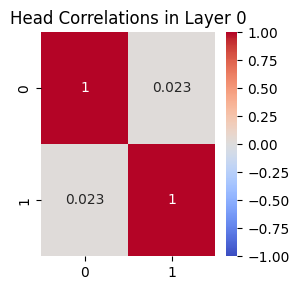

Analyzing correlations between attention heads in Layer 1


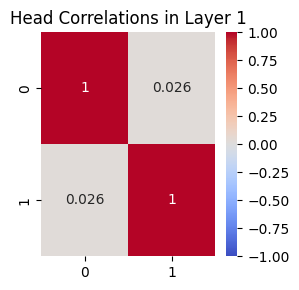

Analyzing correlations between attention heads in Layer 2


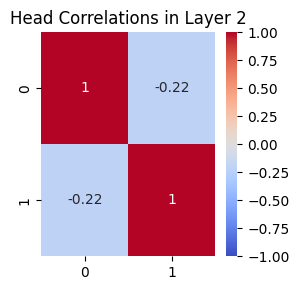

Analyzing correlations between attention heads in Layer 3


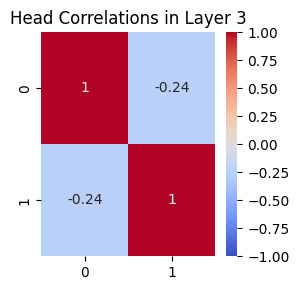

Correlation analysis for GATv2 part
Analyzing correlations between attention heads in Layer 0


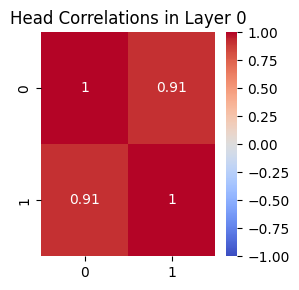

Analyzing correlations between attention heads in Layer 1


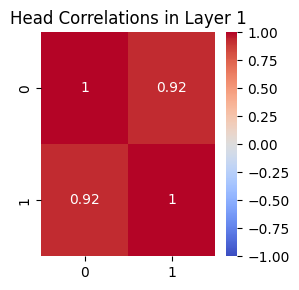

array([[1.        , 0.92476185],
       [0.92476185, 1.        ]])

In [10]:
print("Correlation analysis for Performer part")
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=0, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=1, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=2, model_type='Performer', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=3, model_type='Performer', visualize=True)


print("Correlation analysis for GATv2 part")
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=0, model_type='GATv2', visualize=True)
analyze_head_correlations_within_layer(model, CompleteData, layer_idx=1, model_type='GATv2', visualize=True)

torch.Size([1228, 1228])


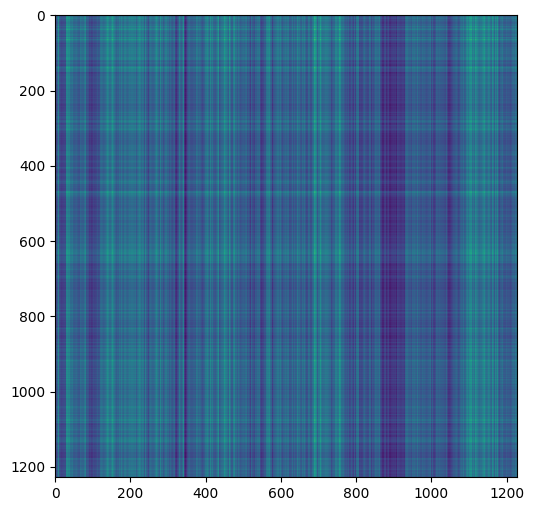

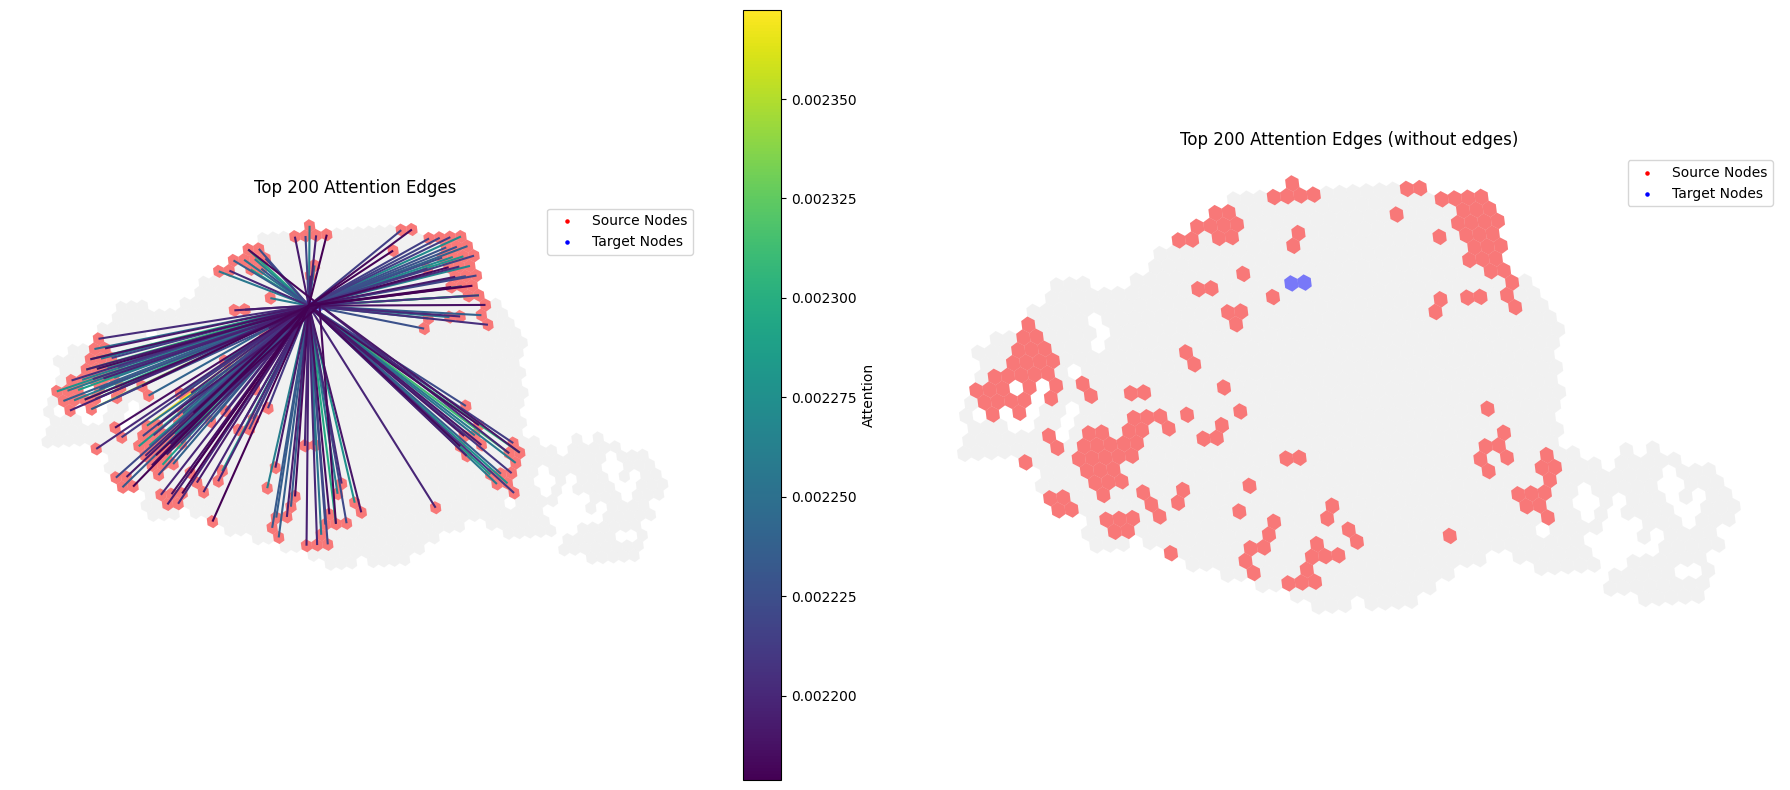

In [11]:
A_flow = make_attention_graph(model, CompleteData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)
f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )
plot_top_k_attention_edges(A_flow.cpu().numpy(), h3_nodes, top_k=200)

Final Test Results - Loss: 0.0036


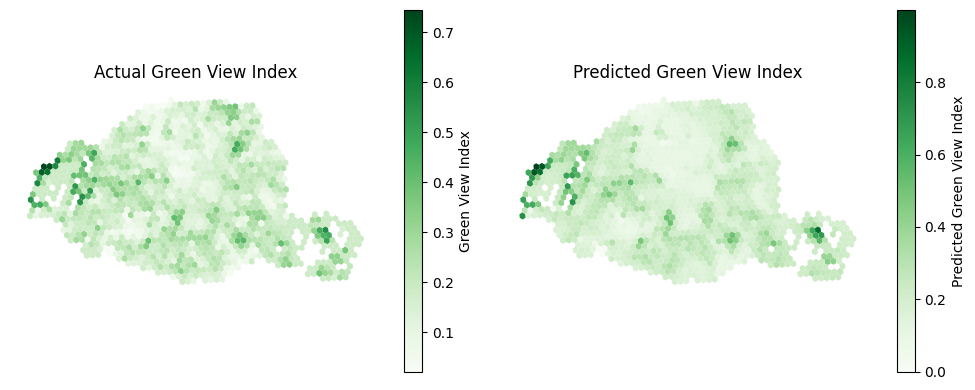

Final Test Results - Loss: 0.0042


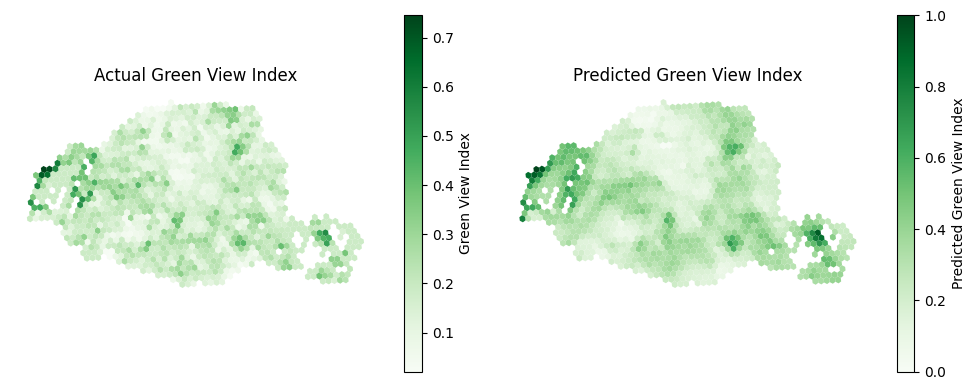

Final Test Results - Loss: 0.0090


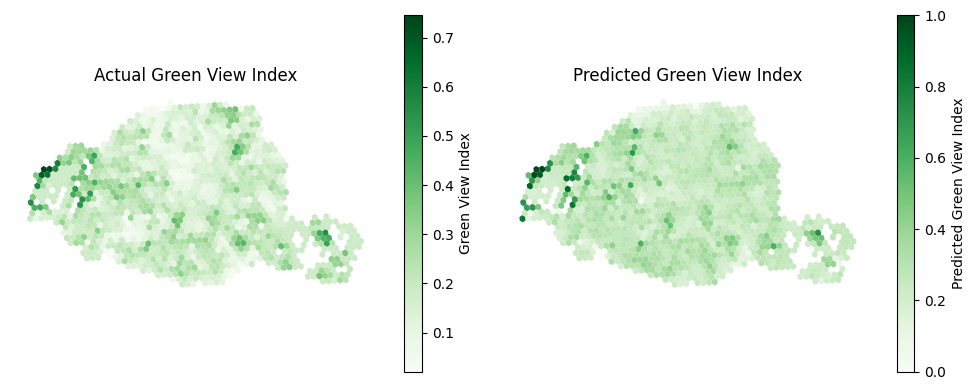

In [12]:
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_hybrid_variant_model.pth', h3_nodes, criterion, branch='both')
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_hybrid_variant_model.pth', h3_nodes, criterion, branch='gat')
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_hybrid_variant_model.pth', h3_nodes, criterion, branch='performer')

As we can see both GAT and Performer learn useful embeddings, but their combination actually improves the performances, so all the results are encouraging.

### Repeating everything with basic data

In [13]:
# Initialize the model
model_basic = HybridModel_variant(
    in_channels=BasicData.num_features,
    pe_input_dim=BasicData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model_basic.to(device)
assert model_basic(BasicData.x, BasicData.pe, BasicData.edge_index).squeeze().shape == BasicData.y.shape, "Model output shape does not match target shape"

In [14]:
LR = 0.001
EPOCHS = 1000
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_basic.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=40)
redraw_freq = 30

# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 100
train_losses, val_losses = [], []
print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_performer(model_basic, BasicData, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(model_basic, BasicData, BasicData.val_mask, criterion)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model_basic.state_dict(), 'best_models_paris/best_hybrid_variant_model_basic.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
    
    # Print progress
    if epoch % 10 == 0:
        test_loss = evaluate(model_basic, BasicData, BasicData.test_mask, criterion)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, Counter: {early_stop_counter}')
    
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 0.0358, Val Loss: 0.0120, Test Loss: 0.0119, Counter: 2
Epoch: 020, Train Loss: 0.0174, Val Loss: 0.0141, Test Loss: 0.0106, Counter: 8
Epoch: 030, Train Loss: 0.0117, Val Loss: 0.0086, Test Loss: 0.0063, Counter: 3
Epoch: 040, Train Loss: 0.0113, Val Loss: 0.0088, Test Loss: 0.0064, Counter: 13
Epoch: 050, Train Loss: 0.0101, Val Loss: 0.0090, Test Loss: 0.0066, Counter: 6
Epoch: 060, Train Loss: 0.0095, Val Loss: 0.0078, Test Loss: 0.0058, Counter: 0
Epoch: 070, Train Loss: 0.0092, Val Loss: 0.0083, Test Loss: 0.0061, Counter: 10
Epoch: 080, Train Loss: 0.0101, Val Loss: 0.0081, Test Loss: 0.0060, Counter: 4
Epoch: 090, Train Loss: 0.0101, Val Loss: 0.0075, Test Loss: 0.0056, Counter: 1
Epoch: 100, Train Loss: 0.0096, Val Loss: 0.0074, Test Loss: 0.0055, Counter: 0
Epoch: 110, Train Loss: 0.0089, Val Loss: 0.0077, Test Loss: 0.0057, Counter: 8
Epoch: 120, Train Loss: 0.0093, Val Loss: 0.0074, Test Loss: 0.0055, Counter: 18
Epoch: 13

Final Test Results - Loss: 0.0048


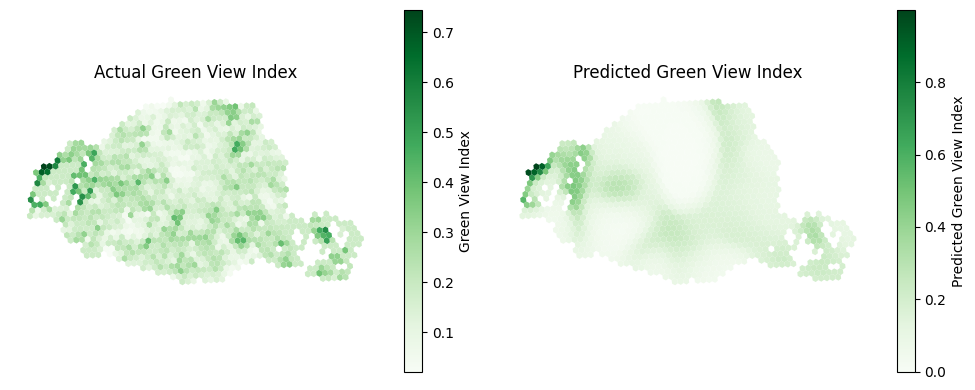

In [15]:
evaluate_and_visualize_predictions(model_basic, BasicData, 'best_models_paris/best_hybrid_variant_model_basic.pth', h3_nodes, criterion)

torch.Size([1228, 1228])


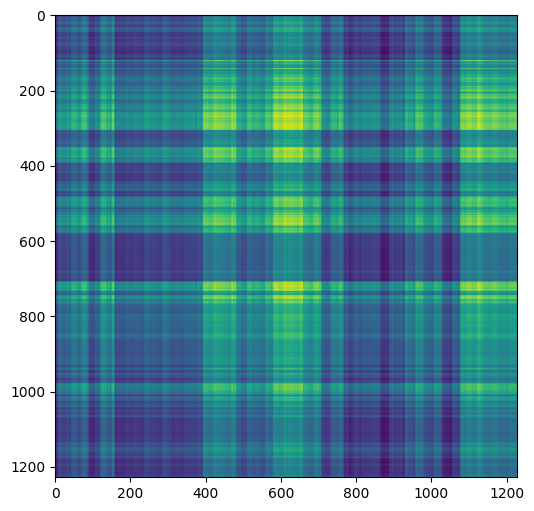

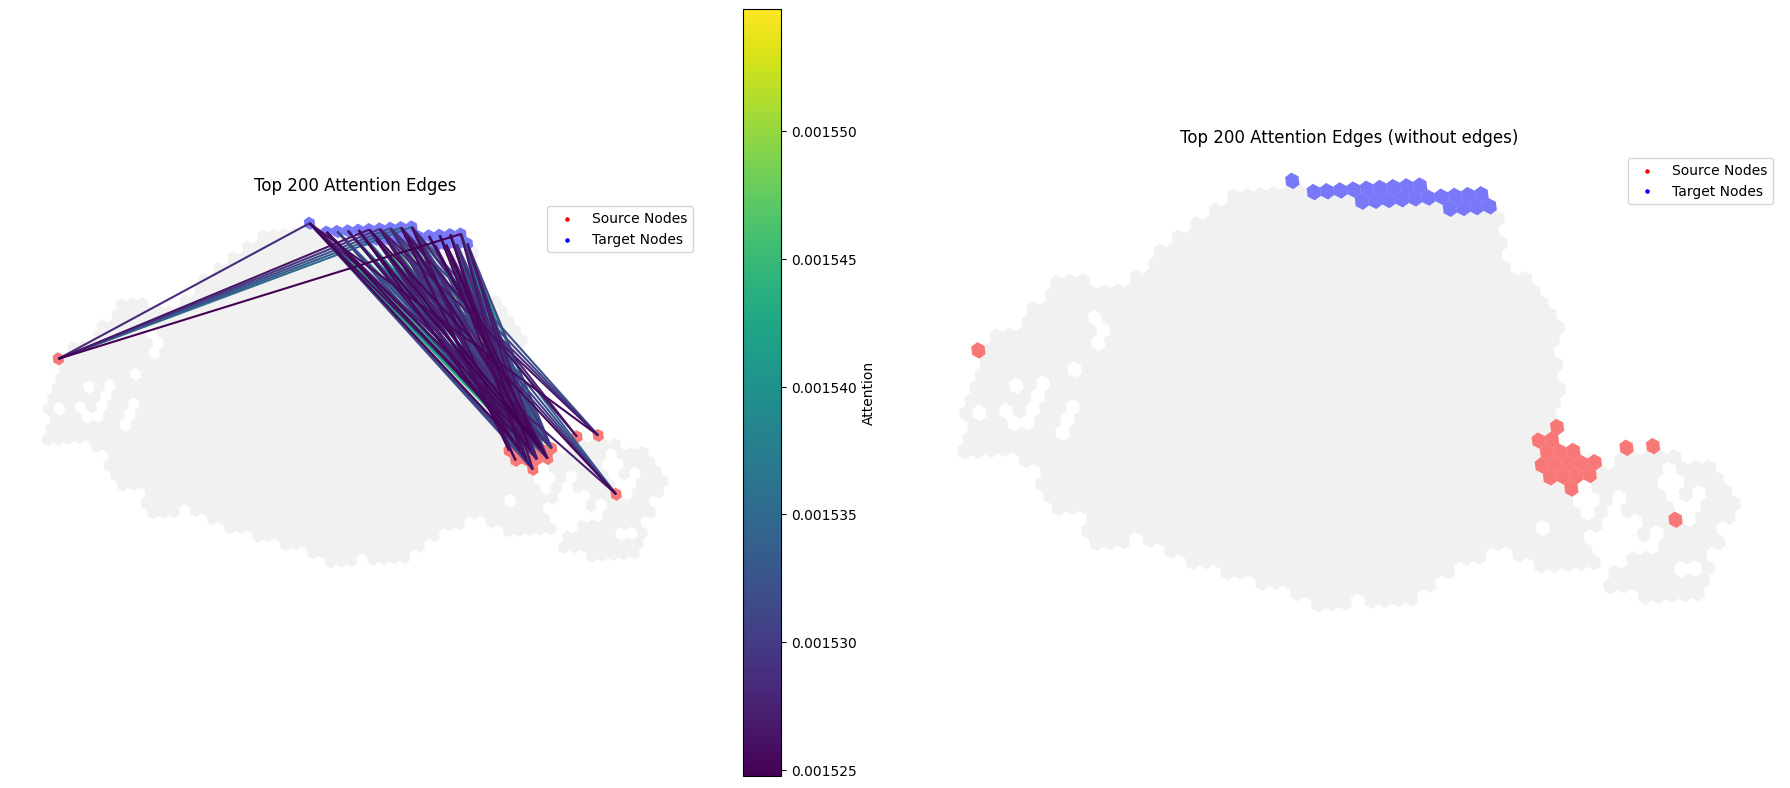

In [16]:
A_flow = make_attention_graph(model_basic, BasicData, model_type= 'Performer' ,fuse="aware")
print(A_flow.shape)
f, ax1 = plt.subplots(1, 1, figsize=(6, 6))
ax1.imshow(A_flow, cmap='viridis', )
plot_top_k_attention_edges(A_flow.cpu().numpy(), h3_nodes, top_k=200)

Final Test Results - Loss: 0.0048


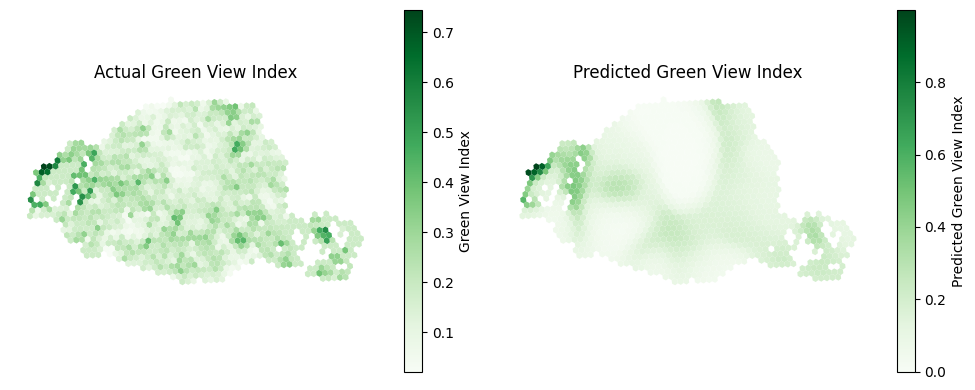

Final Test Results - Loss: 0.0085


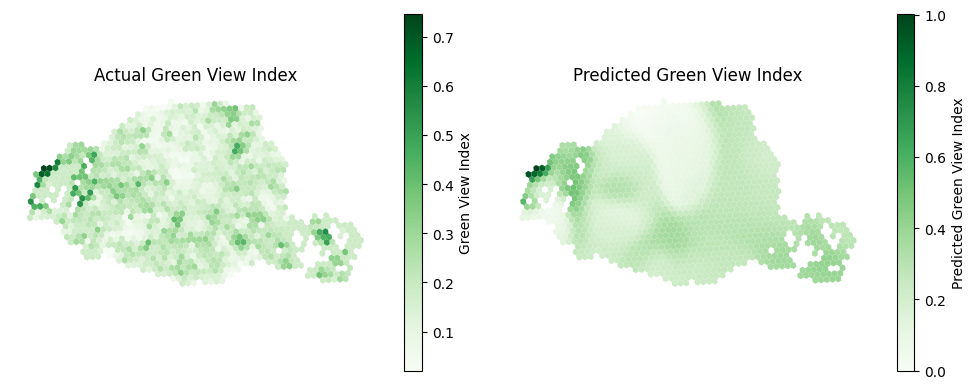

Final Test Results - Loss: 0.0075


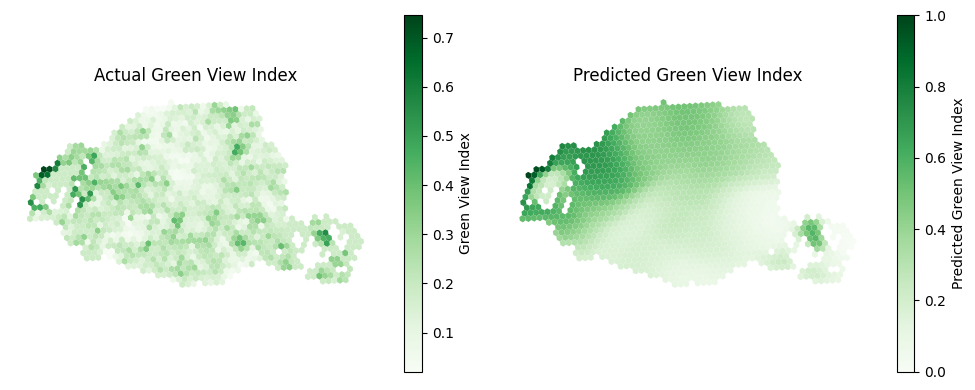

In [17]:
evaluate_and_visualize_predictions(model_basic, BasicData, 'best_models_paris/best_hybrid_variant_model_basic.pth', h3_nodes, criterion, branch='both')
evaluate_and_visualize_predictions(model_basic, BasicData, 'best_models_paris/best_hybrid_variant_model_basic.pth', h3_nodes, criterion, branch='gat')
evaluate_and_visualize_predictions(model_basic, BasicData, 'best_models_paris/best_hybrid_variant_model_basic.pth', h3_nodes, criterion, branch='performer')

# Analysis of the attention weights

First I'm anayzing how the lenghts distributions of the top attentions weights change across layers

In [18]:
model = HybridModelv2(
    in_channels=CompleteData.num_features,
    pe_input_dim=CompleteData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_hybridv2_model.pth')

NameError: name 'HybridModelv2' is not defined

Final Test Results - Loss: 0.0036


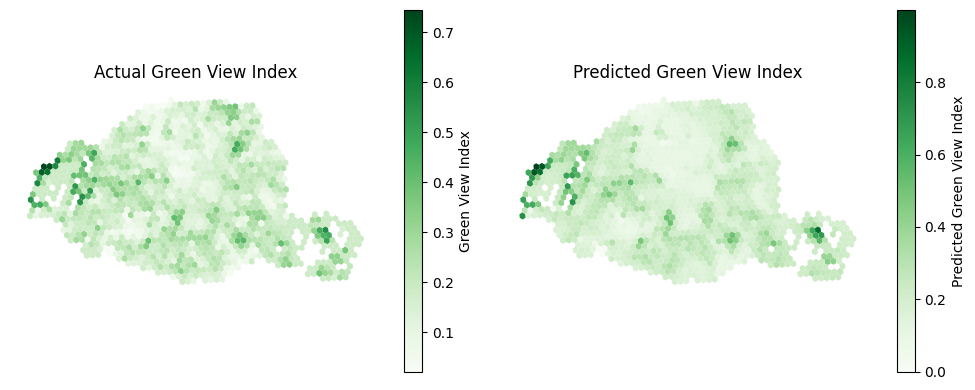

In [20]:
model = HybridModel_variant(
    in_channels=CompleteData.num_features,
    pe_input_dim=CompleteData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model.to(device)
evaluate_and_visualize_predictions(model, CompleteData, 'best_models_paris/best_hybrid_variant_model.pth', h3_nodes, criterion)

In [ ]:
model_basic = HybridModelv2(
    in_channels=BasicData.num_features,
    pe_input_dim=BasicData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model_basic.to(device)
evaluate_and_visualize_predictions(model_basic, BasicData, 'best_models_paris/best_hybridv2_model_basic.pth')

Final Test Results - Loss: 0.0048


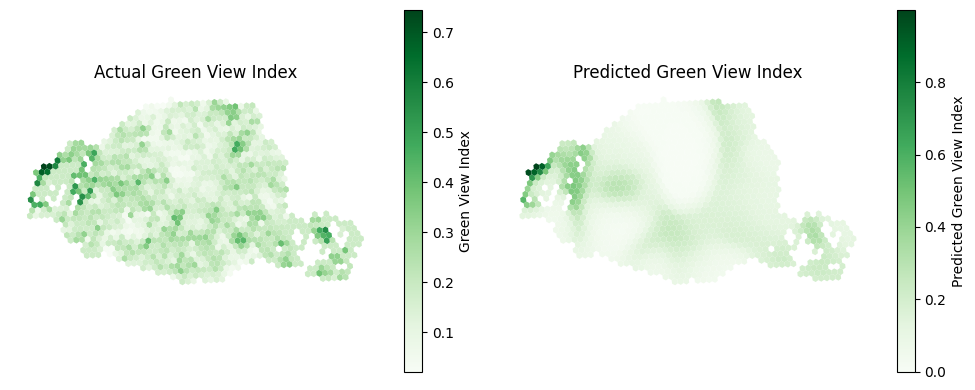

In [21]:
model_basic = HybridModel_variant(
    in_channels=BasicData.num_features,
    pe_input_dim=BasicData.pe.shape[1],
    pe_dim=16,
    hidden_channels=64,
    heads=2,
    head_channels=32,
    num_transformer_layers=4,
    num_gat_layers=4,
    dropout=0.4,
    combine_method='sum'
)
model_basic.to(device)
evaluate_and_visualize_predictions(model_basic, BasicData, 'best_models_paris/best_hybrid_variant_model_basic.pth', h3_nodes, criterion)

In [ ]:
def analyze_attention_distances(model, data, h3_nodes, top_k=200, num_layers=4):
    """
    Analyzes the distribution of attention edge lengths across different layers of the Performer model.
    
    Args:
        model: The trained Performer model
        data: The graph data object
        h3_nodes: GeoDataFrame containing node geometries
        top_k: Number of top attention edges to analyze per layer
        num_layers: Number of layers to analyze
    """

    # Dictionary to store distances by layer
    distances_by_layer = {}
    # DataFrame to store all edge data for more comprehensive analysis
    all_edges_data = []
    
    # Extract attention weights for each layer
    model.eval()
    with torch.no_grad():
        for layer_idx in range(num_layers):
            print(f"Processing layer {layer_idx}...")
            # Get attention scores for this layer
            attention_scores = model.get_performer_attention(
                data.x, data.pe, data.edge_index, layer_idx=layer_idx
            )
            
            # Fuse heads to get a single attention matrix for this layer
            attention_matrix = fuse_heads(
                [attention_scores[h] for h in range(attention_scores.size(0))], 
                method="mean"
            ).cpu().numpy()
            
            # Find top-k attention pairs
            flattened_attn = attention_matrix.flatten()
            top_indices = np.argsort(flattened_attn)[-top_k:][::-1]
            num_nodes = attention_matrix.shape[0]
            sources = top_indices // num_nodes
            targets = top_indices % num_nodes
            
            # Calculate distances for each edge
            distances = []
            
            for i, j, att in zip(sources, targets, flattened_attn[top_indices]):
                source_h3_id = reverse_mapping[i]
                target_h3_id = reverse_mapping[j]
                source_point = h3_nodes.loc[source_h3_id, 'geometry'].centroid
                target_point = h3_nodes.loc[target_h3_id, 'geometry'].centroid
                
                # Calculate Euclidean distance between centroids
                dist = source_point.distance(target_point)
                distances.append(dist)
                
                # Store all edge data for more analysis
                all_edges_data.append({
                    'layer': f'Layer {layer_idx}',
                    'source_idx': i,
                    'target_idx': j,
                    'source_h3': source_h3_id,
                    'target_h3': target_h3_id,
                    'attention': float(att),
                    'distance': dist,
                    'is_self_loop': i == j
                })
            
            # Store distances for this layer
            distances_by_layer[f'Layer {layer_idx}'] = distances
    
    # Create DataFrame for analysis
    edges_df = pd.DataFrame(all_edges_data)
    
    # Distribution of attention edge lengths across layers
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='layer', y='distance', data=edges_df)
    plt.title('Distribution of Top Attention Edge Lengths Across Performer Layers')
    plt.xlabel('Network Layer')
    plt.ylabel('Edge Length (distance between nodes)')
    plt.tight_layout()
    plt.show()
    
    # Histograms of distances for each layer
    fig, axes = plt.subplots(1, num_layers, figsize=(16, 4), sharey=True)
    for i, layer in enumerate(sorted(distances_by_layer.keys())):
        axes[i].hist(distances_by_layer[layer], bins=20, alpha=0.7)
        axes[i].set_title(f'{layer}')
        axes[i].set_xlabel('Edge Length')
        if i == 0:
            axes[i].set_ylabel('Frequency')
    plt.tight_layout()
    plt.suptitle('Histograms of Attention Edge Lengths by Layer', y=1.05)
    plt.show()
    
   
    layer_means = []
    layer_medians = []
    
    for layer in sorted(edges_df['layer'].unique()):
        layer_df = edges_df[edges_df['layer'] == layer]
        
        # Compute mean and median distances
        mean_dist = layer_df['distance'].mean()
        median_dist = layer_df['distance'].median()
        layer_means.append({'Layer': layer, 'Mean Distance': mean_dist})
        layer_medians.append({'Layer': layer, 'Median Distance': median_dist})
    

    
    # Plot mean and median distances by layer
    means_df = pd.DataFrame(layer_means)
    medians_df = pd.DataFrame(layer_medians)
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(x='Layer', y='Mean Distance', data=means_df, ax=ax[0])
    ax[0].set_title('Mean Attention Edge Distance by Layer')
    ax[0].set_ylabel('Mean Distance')
    
    sns.barplot(x='Layer', y='Median Distance', data=medians_df, ax=ax[1])
    ax[1].set_title('Median Attention Edge Distance by Layer')
    ax[1].set_ylabel('Median Distance')
    plt.tight_layout()
    plt.show()
    
    # Print statistical summary
    print("\nStatistical summary of edge lengths by layer:")
    for layer, distances in distances_by_layer.items():
        print(f"\n{layer}:")
        print(f"  Mean distance: {np.mean(distances):.4f}")
        print(f"  Median distance: {np.median(distances):.4f}")
        print(f"  Min distance: {np.min(distances):.4f}")
        print(f"  Max distance: {np.max(distances):.4f}")
        print(f"  Standard deviation: {np.std(distances):.4f}")

In [ ]:
print("Analyzing for the model trained on CompleteData...")
analyze_attention_distances(model, CompleteData, h3_nodes, top_k=100, num_layers=4)

In [ ]:
print("Analyzing for the model trained on BasicData ...")
analyze_attention_distances(model_basic, BasicData, h3_nodes, top_k=100, num_layers=4)

Then I'm analyzing the attention weights distriburions

In [22]:
def analyze_attention_weight_distributions(model, data, num_layers=4):
    """
    Analyzes the distribution of attention weights across different layers.
    
    Args:
        model: The trained Performer model
        data: The graph data object
        num_layers: Number of layers to analyze
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns
    from scipy import stats
    
    # Storage for attention weights
    all_attention_data = []
    
    # Extract attention weights for each layer
    model.eval()
    with torch.no_grad():
        for layer_idx in range(num_layers):
            print(f"Processing layer {layer_idx}...")
            
            # Get attention scores for this layer
            attention_scores = model.get_performer_attention(
                data.x, data.pe, data.edge_index, layer_idx=layer_idx
            )
            
            # Process each head
            for head_idx in range(attention_scores.size(0)):
                # Extract attention weights for this head
                attn_matrix = attention_scores[head_idx].cpu().numpy()
                
                # Get flattened weights and corresponding indices
                attn_weights = attn_matrix.flatten()
                num_nodes = attn_matrix.shape[0]
                
                # Generate source and target indices
                sources = np.repeat(np.arange(num_nodes), num_nodes)
                targets = np.tile(np.arange(num_nodes), num_nodes)
                
                # Store each attention weight with its source and target
                for source, target, weight in zip(sources, targets, attn_weights):
                    all_attention_data.append({
                        'layer': f'Layer {layer_idx}',
                        'head': f'Head {head_idx}',
                        'source': int(source),
                        'target': int(target),
                        'weight': float(weight)
                    })
                # Basic statistics for this head
                print(f"  Layer {layer_idx}, Head {head_idx}:")
                print(f"    Mean: {np.mean(attn_weights):.6f}")
                print(f"    Median: {np.median(attn_weights):.6f}")
                print(f"    Min: {np.min(attn_weights):.6f}")
                print(f"    Max: {np.max(attn_weights):.6f}")
                print(f"    Std: {np.std(attn_weights):.6f}")
                
                
                
    
    # Create DataFrame for visualization
    attn_df = pd.DataFrame(all_attention_data)
    
    # 1. Plot histograms of attention weights for each layer (combine all heads)
    plt.figure(figsize=(16, 8))
    for i, layer in enumerate(sorted(attn_df['layer'].unique())):
        layer_data = attn_df[attn_df['layer'] == layer]['weight']
        
        # Plot histogram with kernel density estimate
        sns.histplot(layer_data, kde=True, stat='density', alpha=0.6, 
                   label=layer)
    
    plt.title('Distribution of Attention Weights Across Layers', fontsize=14)
    plt.xlabel('Attention Weight', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    
    # 2. Facet grid to show distribution for each layer/head combination
    g = sns.FacetGrid(attn_df, col='layer', row='head', height=3, aspect=1.5)
    g.map_dataframe(sns.histplot, x='weight', kde=True)
    g.set_titles(col_template="{col_name}", row_template="{row_name}")
    g.set_axis_labels("Attention Weight", "Count")
    g.tight_layout()
    plt.show()

    return attn_df

Analyzing for the model trained on CompleteData...
Processing layer 0...
  Layer 0, Head 0:
    Mean: 0.000814
    Median: 0.000771
    Min: 0.000025
    Max: 0.003471
    Std: 0.000338
  Layer 0, Head 1:
    Mean: 0.000814
    Median: 0.000786
    Min: 0.000048
    Max: 0.002845
    Std: 0.000285
Processing layer 1...
  Layer 1, Head 0:
    Mean: 0.000814
    Median: 0.000792
    Min: 0.000081
    Max: 0.002348
    Std: 0.000276
  Layer 1, Head 1:
    Mean: 0.000814
    Median: 0.000801
    Min: 0.000086
    Max: 0.002108
    Std: 0.000221
Processing layer 2...
  Layer 2, Head 0:
    Mean: 0.000814
    Median: 0.000817
    Min: 0.000140
    Max: 0.001641
    Std: 0.000196
  Layer 2, Head 1:
    Mean: 0.000814
    Median: 0.000805
    Min: 0.000166
    Max: 0.002223
    Std: 0.000145
Processing layer 3...
  Layer 3, Head 0:
    Mean: 0.000814
    Median: 0.000813
    Min: 0.000282
    Max: 0.001623
    Std: 0.000122
  Layer 3, Head 1:
    Mean: 0.000814
    Median: 0.000813
    Min: 0.

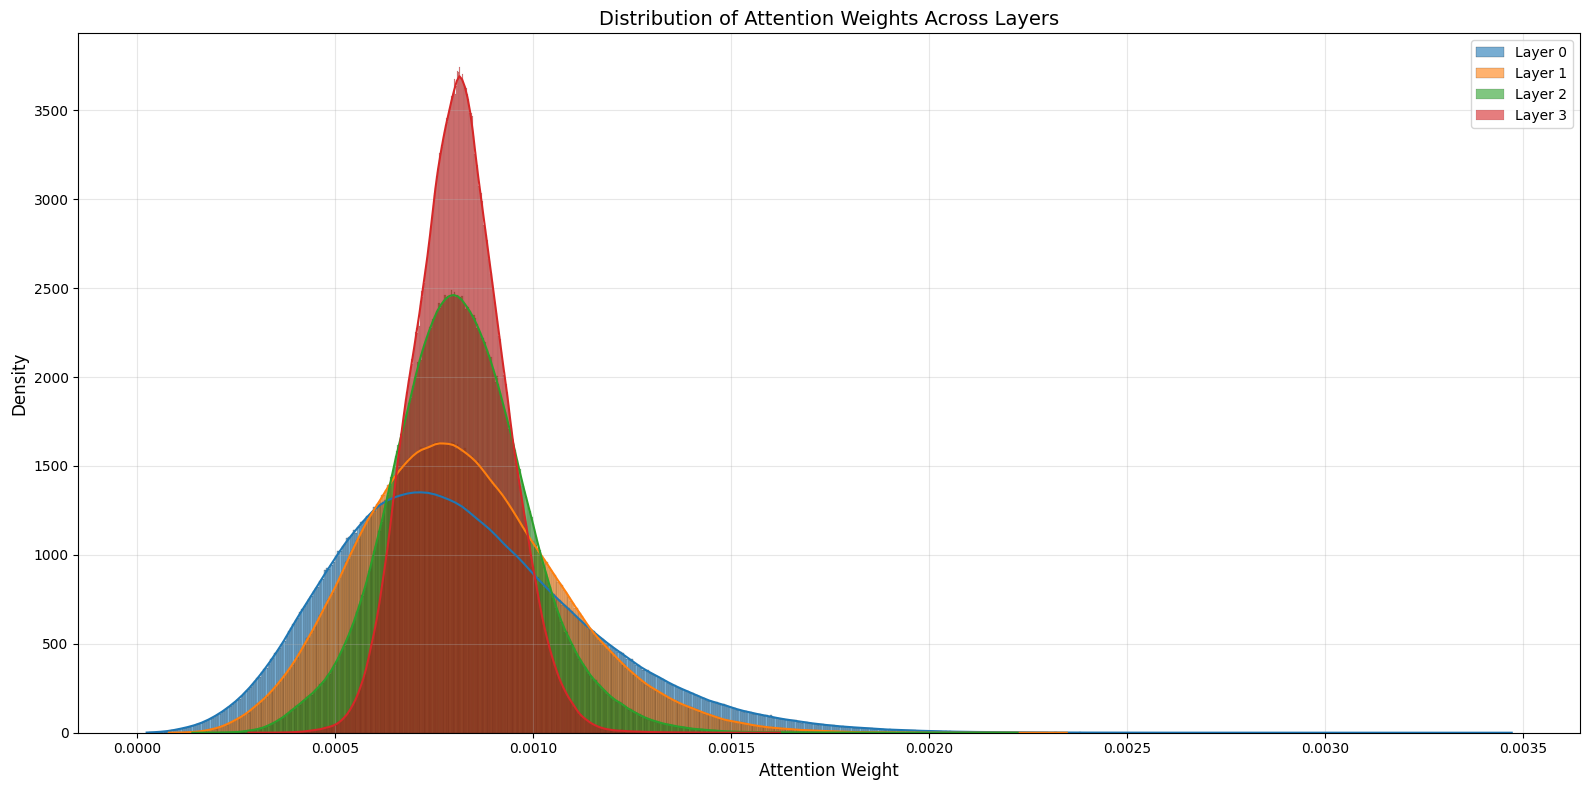

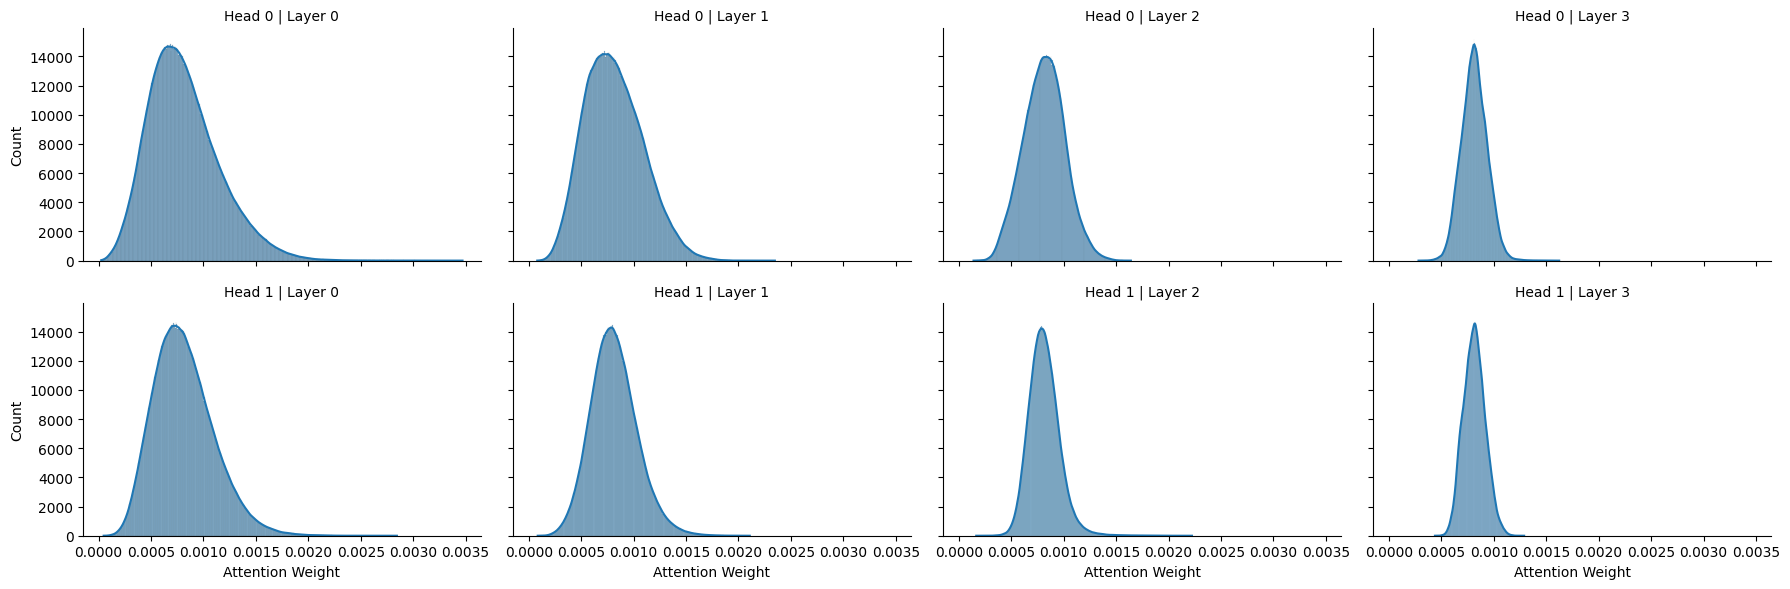

,layer,head,source,target,weight
0,Layer 0,Head 0,0,0,0.001004
1,Layer 0,Head 0,0,1,0.001154
2,Layer 0,Head 0,0,2,0.001089
3,Layer 0,Head 0,0,3,0.001172
4,Layer 0,Head 0,0,4,0.001058
...,...,...,...,...,...
12063867,Layer 3,Head 1,1227,1223,0.000947
12063868,Layer 3,Head 1,1227,1224,0.001004
12063869,Layer 3,Head 1,1227,1225,0.000995
12063870,Layer 3,Head 1,1227,1226,0.000719


In [23]:
print("Analyzing for the model trained on CompleteData...")
analyze_attention_weight_distributions(model, CompleteData, num_layers=4)

Analyzing for the model trained on BasicData ...
Processing layer 0...
  Layer 0, Head 0:
    Mean: 0.000814
    Median: 0.000824
    Min: 0.000056
    Max: 0.001972
    Std: 0.000382
  Layer 0, Head 1:
    Mean: 0.000814
    Median: 0.000644
    Min: 0.000028
    Max: 0.003348
    Std: 0.000542
Processing layer 1...
  Layer 1, Head 0:
    Mean: 0.000814
    Median: 0.000783
    Min: 0.000088
    Max: 0.002007
    Std: 0.000346
  Layer 1, Head 1:
    Mean: 0.000814
    Median: 0.000783
    Min: 0.000086
    Max: 0.002016
    Std: 0.000368
Processing layer 2...
  Layer 2, Head 0:
    Mean: 0.000814
    Median: 0.000794
    Min: 0.000374
    Max: 0.001295
    Std: 0.000138
  Layer 2, Head 1:
    Mean: 0.000814
    Median: 0.000773
    Min: 0.000303
    Max: 0.002031
    Std: 0.000241
Processing layer 3...
  Layer 3, Head 0:
    Mean: 0.000814
    Median: 0.000809
    Min: 0.000562
    Max: 0.001144
    Std: 0.000088
  Layer 3, Head 1:
    Mean: 0.000814
    Median: 0.000809
    Min: 0.00

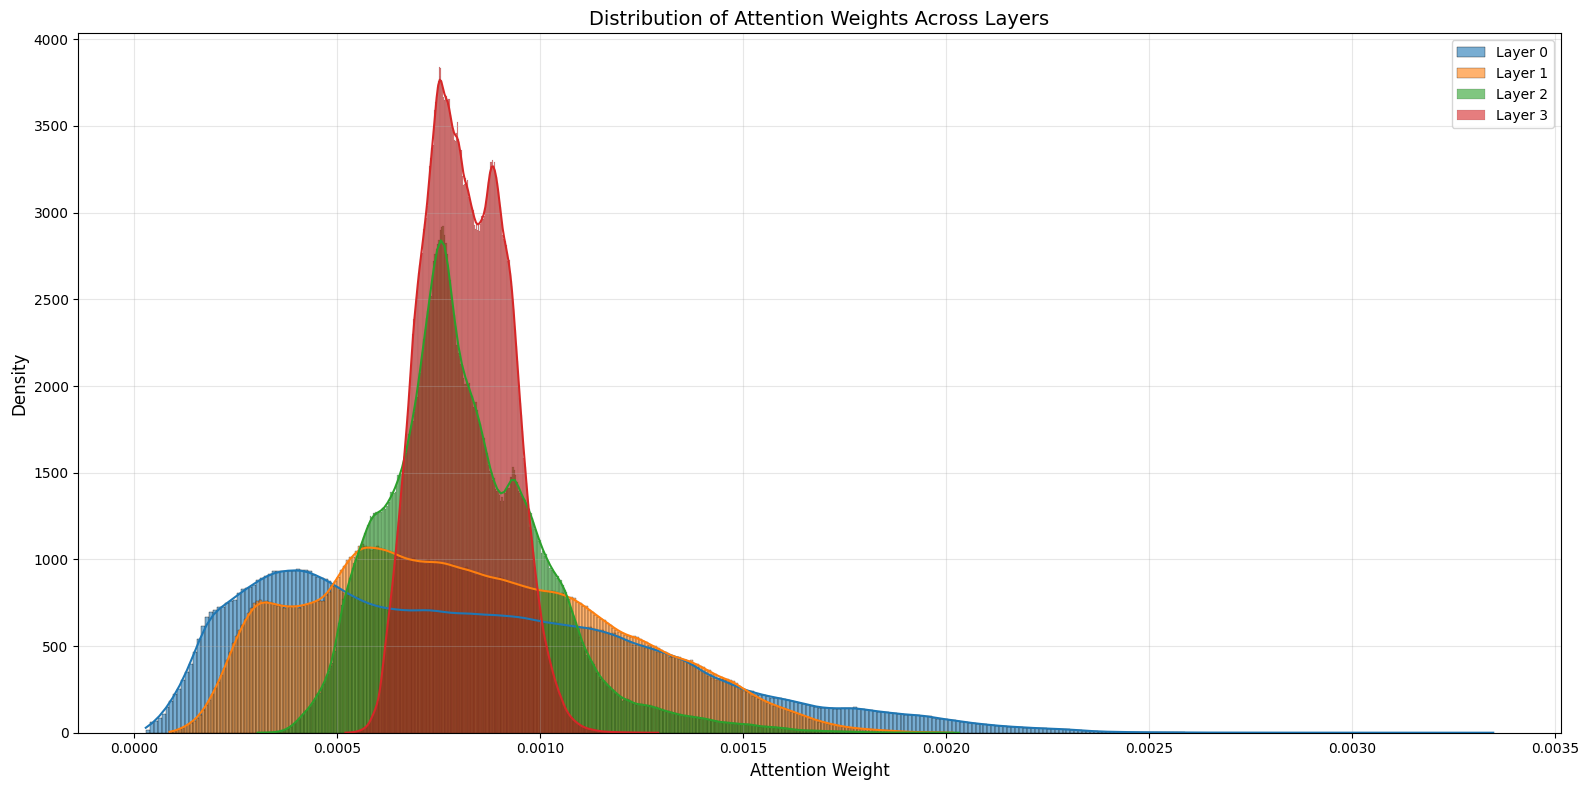

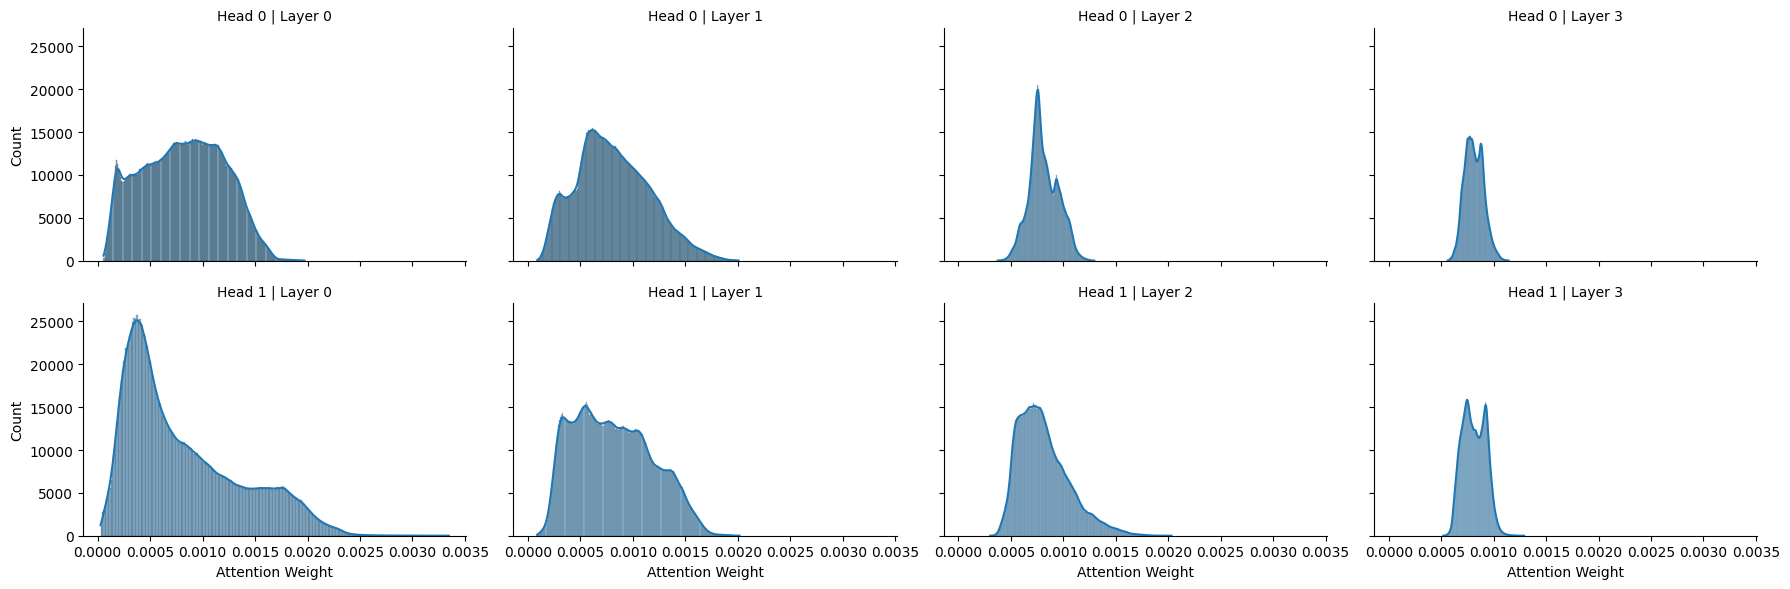

In [24]:
print("Analyzing for the model trained on BasicData ...")
attn_df = analyze_attention_weight_distributions(model_basic, BasicData, num_layers=4)

We can see that we have two clear diffirent behaviors:
- CompleteData shows more uniform, smoother patterns;
- BasicData shows distinct modes, distinct peaks.

This results need more investigation, but are already interesting. Now I will try to see whether the different modes are related to the different types of nodes in the dataset.

Let's separate the modes in the distribution

In [ ]:
attn_df.to_csv('attention_weights_basic_gpslike.csv', index=True)

The work will continue in the next notebook!